In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt


#read in + edit SP 500 value
sp500_df = pd.read_csv("sp500adj.csv")
sp500_df['Date'] = pd.to_datetime(sp500_df['Date'])
sp500_df['date_month'] = sp500_df['Date'].dt.strftime('%Y.%m')
sp500_df = sp500_df.rename(columns={"Value":"SP500 Index Value ($)"})
#sp500_df


#read in + edit geopolitical risk (GPR)
#"Higher geopolitical risk foreshadows lower investment, stock prices, and employment"
gpr_df_raw = pd.read_csv("data_gpr_export.csv")
gpr_df_raw['Date'] = pd.to_datetime(gpr_df_raw['month'])
gpr_df_raw['date_month'] = gpr_df_raw['Date'].dt.strftime('%Y.%m')
us_gpr_df = gpr_df_raw[['date_month','GPRC_USA']]


#read in + edit GDP with inflation adjusted
#note: had to remove first two lines in the dataset in order to actually read it
#those only contained the data source and last edit time:
#"Data Source","World Development Indicators",
#"Last Updated Date","2025-10-07",
GDP_df = pd.read_csv("GDP/API_NY.GDP.MKTP.CD_DS2_en_csv_v2_130122.csv")
GDP_df = GDP_df[GDP_df['Country Code'] == 'USA']
gdp_usa = GDP_df.melt(
    id_vars=['Country Code','Country Name','Indicator Name','Indicator Code'],
    var_name='Year', value_name='GDP'
)
gdp_usa = gdp_usa.rename(columns={"GDP":"US GDP inflation adjusted ($)"})
gdp_usa = gdp_usa[gdp_usa['Year'].str.isnumeric()].copy()
gdp_usa['Year'] = gdp_usa['Year'].astype(int)
#gdp_usa


#read in + edit federal funds rate
fed_df = pd.read_csv("FEDFUNDS.csv")
fed_df['observation_date'] = pd.to_datetime(fed_df['observation_date'])
fed_df['Year'] = fed_df['observation_date'].dt.year
fed_df['FEDFUNDS'] = pd.to_numeric(fed_df['FEDFUNDS'], errors='coerce')
fed_df = fed_df.groupby('Year', as_index=False)['FEDFUNDS'].mean()


#read in + edit CPI (Consumer Price Index)
cpi_df = pd.read_csv("CPIAUCSL.csv")
cpi_df['observation_date'] = pd.to_datetime(cpi_df['observation_date'])
cpi_df['Year'] = cpi_df['observation_date'].dt.year
cpi_df['CPIAUCSL'] = pd.to_numeric(cpi_df['CPIAUCSL'], errors='coerce')
cpi_df = cpi_df.groupby('Year', as_index=False)['CPIAUCSL'].mean()
cpi_df = cpi_df.rename(columns={"CPIAUCSL":"CPI"})


#read in + edit unemployment rate
unrate_df = pd.read_csv("UNRATE.csv")
unrate_df['observation_date'] = pd.to_datetime(unrate_df['observation_date'])
unrate_df['Year'] = unrate_df['observation_date'].dt.year
unrate_df['UNRATE'] = pd.to_numeric(unrate_df['UNRATE'], errors='coerce')
unrate_df = unrate_df.groupby('Year', as_index=False)['UNRATE'].mean()
unrate_df = unrate_df.rename(columns={"UNRATE":"UNEMPLOYMENT RATE"})


#read in + edit VIX (Volatility Index)
vix_df = pd.read_csv("VIXCLS.csv")
vix_df['observation_date'] = pd.to_datetime(vix_df['observation_date'])
vix_df['Year'] = vix_df['observation_date'].dt.year
vix_df['VIXCLS'] = pd.to_numeric(vix_df['VIXCLS'], errors='coerce')
vix_df = vix_df.groupby('Year', as_index=False)['VIXCLS'].mean()
vix_df = vix_df.rename(columns={"VIXCLS":"VIX"})


#merging all the dataframes (by year)
merged_df = pd.merge(sp500_df, us_gpr_df, on='date_month', how='inner').dropna()
merged_df['Year'] = merged_df['Date'].dt.year
annual_df = merged_df.groupby('Year', as_index=False).agg({
    'SP500 Index Value ($)': 'mean',
    'GPRC_USA': 'mean'
})
merged_yearly_df = pd.merge(annual_df, gdp_usa[['Year','US GDP inflation adjusted ($)']], on='Year', how='inner')
merged_yearly_df = pd.merge(merged_yearly_df, fed_df, on='Year', how='left')
merged_yearly_df = pd.merge(merged_yearly_df, cpi_df, on='Year', how='left')
merged_yearly_df = pd.merge(merged_yearly_df, unrate_df, on='Year', how='left')
merged_yearly_df = pd.merge(merged_yearly_df, vix_df, on='Year', how='left')


#merging all the datasets (by year + month, doesn't include GDP)
merged_df = pd.merge(sp500_df, us_gpr_df, on='date_month', how='inner').dropna()
fed_df = pd.read_csv("FEDFUNDS.csv")
fed_df['observation_date'] = pd.to_datetime(fed_df['observation_date'])
fed_df['date_month'] = fed_df['observation_date'].dt.strftime('%Y.%m')
fed_df = fed_df[['date_month', 'FEDFUNDS']]
merged_monthly_df = pd.merge(merged_df, fed_df, on='date_month', how='left')

#read in + edit CPI for monthly merge
cpi_df_monthly = pd.read_csv("CPIAUCSL.csv")
cpi_df_monthly['observation_date'] = pd.to_datetime(cpi_df_monthly['observation_date'])
cpi_df_monthly['date_month'] = cpi_df_monthly['observation_date'].dt.strftime('%Y.%m')
cpi_df_monthly['CPIAUCSL'] = pd.to_numeric(cpi_df_monthly['CPIAUCSL'], errors='coerce')
cpi_df_monthly = cpi_df_monthly.groupby('date_month', as_index=False)['CPIAUCSL'].mean()
cpi_df_monthly = cpi_df_monthly.rename(columns={"CPIAUCSL":"CPI"})
cpi_df_monthly = cpi_df_monthly[['date_month', 'CPI']]

#read in + edit unemployment rate for monthly merge
unrate_df_monthly = pd.read_csv("UNRATE.csv")
unrate_df_monthly['observation_date'] = pd.to_datetime(unrate_df_monthly['observation_date'])
unrate_df_monthly['date_month'] = unrate_df_monthly['observation_date'].dt.strftime('%Y.%m')
unrate_df_monthly['UNRATE'] = pd.to_numeric(unrate_df_monthly['UNRATE'], errors='coerce')
unrate_df_monthly = unrate_df_monthly.groupby('date_month', as_index=False)['UNRATE'].mean()
unrate_df_monthly = unrate_df_monthly.rename(columns={"UNRATE":"UNEMPLOYMENT RATE"})
unrate_df_monthly = unrate_df_monthly[['date_month', 'UNEMPLOYMENT RATE']]

#read in + edit VIX for monthly merge
vix_df_monthly = pd.read_csv("VIXCLS.csv")
vix_df_monthly['observation_date'] = pd.to_datetime(vix_df_monthly['observation_date'])
vix_df_monthly['date_month'] = vix_df_monthly['observation_date'].dt.strftime('%Y.%m')
vix_df_monthly['VIXCLS'] = pd.to_numeric(vix_df_monthly['VIXCLS'], errors='coerce')
vix_df_monthly = vix_df_monthly.groupby('date_month', as_index=False)['VIXCLS'].mean()
vix_df_monthly = vix_df_monthly.rename(columns={"VIXCLS":"VIX"})
vix_df_monthly = vix_df_monthly[['date_month', 'VIX']]

#merge all monthly datasets
merged_monthly_df = pd.merge(merged_monthly_df, cpi_df_monthly, on='date_month', how='left')
merged_monthly_df = pd.merge(merged_monthly_df, unrate_df_monthly, on='date_month', how='left')
merged_monthly_df = pd.merge(merged_monthly_df, vix_df_monthly, on='date_month', how='left')
merged_monthly_df = merged_monthly_df.sort_values('Date')
merged_monthly_df = merged_monthly_df.set_index('Date')

# Rename columns: CPIAUCSL -> CPI, UNRATE -> UNEMPLOYMENT RATE, VIXCLS -> VIX
merged_monthly_df = merged_monthly_df.rename(columns={
    'CPIAUCSL': 'CPI',
    'UNRATE': 'UNEMPLOYMENT RATE',
    'VIXCLS': 'VIX'
})

# Rename columns in yearly dataset
merged_yearly_df = merged_yearly_df.rename(columns={
    'CPIAUCSL': 'CPI',
    'UNRATE': 'UNEMPLOYMENT RATE',
    'VIXCLS': 'VIX'
})

# To view the datasets, uncomment the following:
# merged_monthly_df
# merged_yearly_df

## data view
You can check Yearly dataset -> merged_yearly_df
You can check Monyhly dataset -> merged_monthly_df

In [35]:
# Add CHANGE RATE columns for each feature showing percentage change from previous month/year
# For merged_monthly_df and merged_yearly_df

import numpy as np

# Function to add CHANGE RATE columns next to each numeric column
def add_change_rate_columns(df, exclude_cols=None):
    """
    Add CHANGE RATE columns next to each numeric column.
    Each row shows the percentage change from the previous period.
    """
    if exclude_cols is None:
        exclude_cols = []
    
    df_with_changes = df.copy()
    
    # Get numeric columns excluding specified ones
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col not in exclude_cols]
    
    # Create new dataframe with reordered columns
    new_columns = []
    
    for col in df.columns:
        new_columns.append(col)
        # If this is a numeric column, add CHANGE RATE column right after it
        if col in numeric_cols:
            change_col_name = col.replace(' Index Value ($)', ' CHANGE RATE').replace(' ($)', ' CHANGE RATE').replace('_', ' ').title().replace(' ', ' ') + ' CHANGE RATE'
            # Simplify the name
            if 'SP500' in col:
                change_col_name = 'SP500 CHANGE RATE'
            elif 'GPRC_USA' in col or 'GPRC' in col:
                change_col_name = 'GPRC CHANGE RATE'
            elif 'FEDFUNDS' in col or 'FEDFUNDS' in col:
                change_col_name = 'FEDFUNDS CHANGE RATE'
            elif 'CPI' in col and 'CHANGE' not in col:
                change_col_name = 'CPI CHANGE RATE'
            elif 'UNEMPLOYMENT' in col or 'UNRATE' in col:
                change_col_name = 'UNEMPLOYMENT RATE CHANGE RATE'
            elif 'VIX' in col and 'CHANGE' not in col:
                change_col_name = 'VIX CHANGE RATE'
            elif 'GDP' in col:
                change_col_name = 'GDP CHANGE RATE'
            
            # Calculate percentage change
            df_with_changes[change_col_name] = df[col].pct_change(fill_method=None) * 100
            new_columns.append(change_col_name)
    
    # Reorder columns
    df_with_changes = df_with_changes[new_columns]
    
    return df_with_changes

# Apply to merged_monthly_df
merged_monthly_df_with_changes = add_change_rate_columns(merged_monthly_df, exclude_cols=['date_month'])

# Apply to merged_yearly_df
merged_yearly_df_with_changes = add_change_rate_columns(merged_yearly_df, exclude_cols=['Year'])

# To view the datasets, uncomment the following:
# merged_monthly_df_with_changes
merged_yearly_df_with_changes



,Year,SP500 Index Value ($),SP500 CHANGE RATE,GPRC_USA,GPRC CHANGE RATE,US GDP inflation adjusted ($),GDP CHANGE RATE,FEDFUNDS,FEDFUNDS CHANGE RATE,CPI,CPI CHANGE RATE,UNEMPLOYMENT RATE,UNEMPLOYMENT RATE CHANGE RATE,VIX,VIX CHANGE RATE
0,1985,566.486667,NaN,2.627873,NaN,4.338979e+12,NaN,8.100833,NaN,107.600000,NaN,7.191667,NaN,NaN,NaN
1,1986,703.105000,24.116778,2.730073,3.889066,4.579631e+12,5.546282,6.805000,-15.996297,109.691667,1.943928,7.000000,-2.665122,NaN,NaN
2,1987,812.250833,15.523405,2.626466,-3.795040,4.855215e+12,6.017603,6.657500,-2.167524,113.616667,3.578212,6.175000,-11.785714,NaN,NaN
3,1988,731.063333,-9.995373,2.235698,-14.878076,5.236438e+12,7.851825,7.568333,13.681312,118.275000,4.100044,5.491667,-11.066127,NaN,NaN
4,1989,848.495000,16.063132,2.211056,-1.102213,5.641580e+12,7.736977,9.216667,21.779344,123.941667,4.791094,5.258333,-4.248862,NaN,NaN
5,1990,821.929167,-3.130936,3.046096,37.766581,5.963144e+12,5.699893,8.099167,-12.124774,130.658333,5.419216,5.616667,6.814580,23.063478,NaN
6,1991,903.460833,9.919549,3.636313,19.376192,6.158129e+12,3.269836,5.687500,-29.776726,136.166667,4.215830,6.850000,21.958457,18.373373,-20.335637
7,1992,958.810000,6.126349,1.940122,-46.645907,6.520327e+12,5.881624,3.521667,-38.080586,140.308333,3.041616,7.491667,9.367397,15.452047,-15.899779
8,1993,1012.428333,5.592175,2.220524,14.452809,6.858559e+12,5.187347,3.022500,-14.174160,144.475000,2.969650,6.908333,-7.786429,12.686245,-17.899260
9,1994,1002.550000,-0.975707,2.226595,0.273387,7.287236e+12,6.250249,4.201667,39.012958,148.225000,2.595605,6.100000,-11.700844,13.925516,9.768618


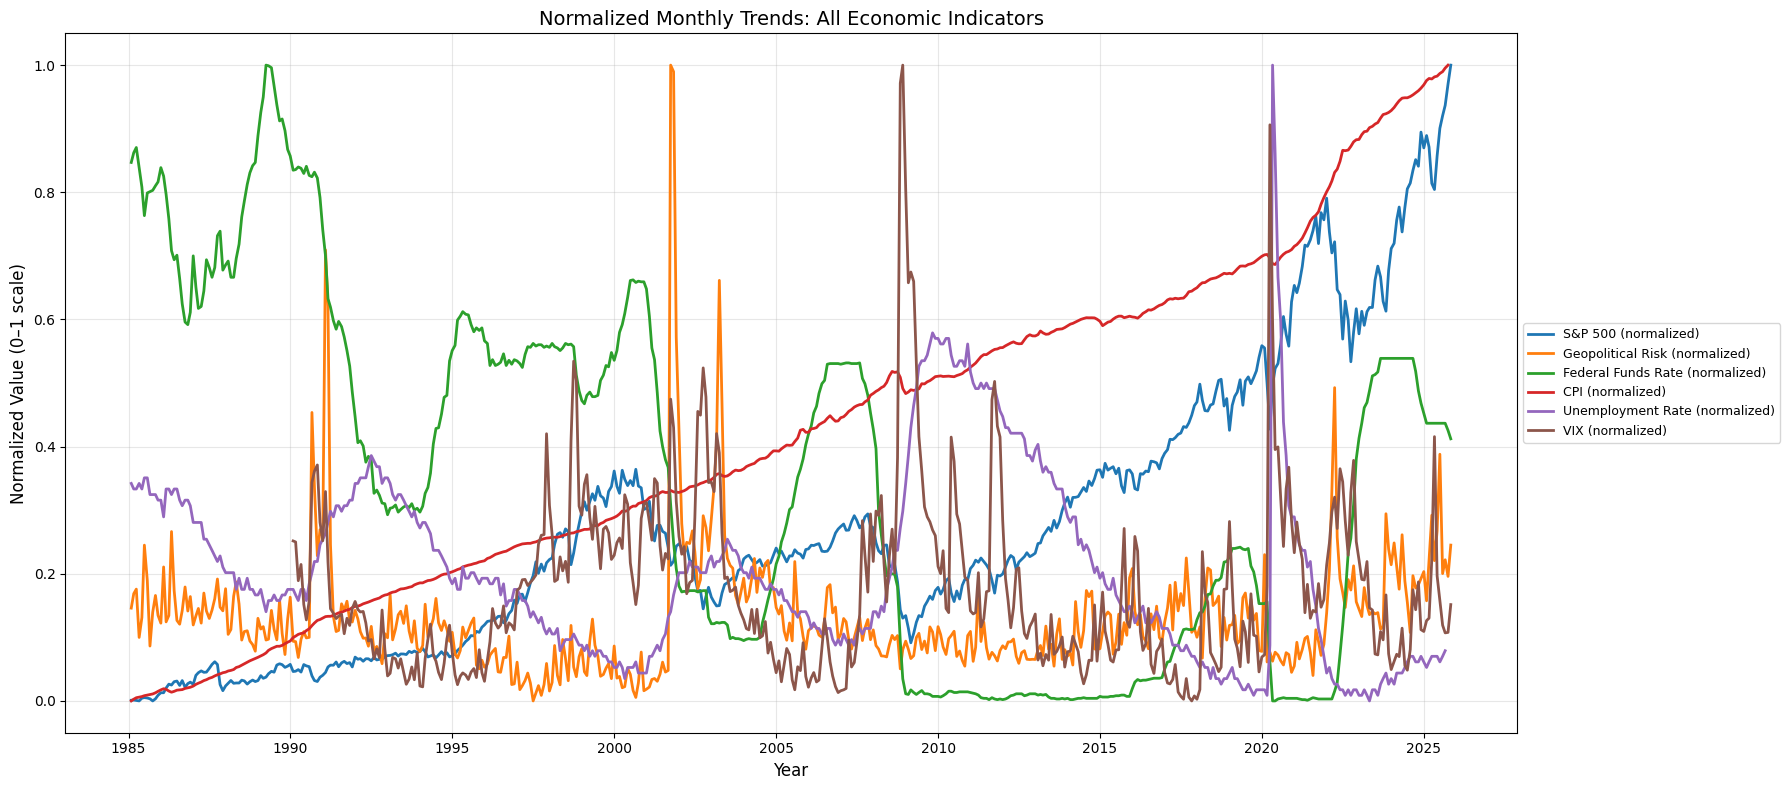

In [36]:
# Normalized graph for monthly dataset
normalized_df = merged_monthly_df.copy()

# Normalize all numeric columns
original_cols = ['SP500 Index Value ($)', 'GPRC_USA', 'FEDFUNDS', 'CPI', 'UNEMPLOYMENT RATE', 'VIX']

# Normalize original columns
for col in original_cols:
    if col in normalized_df.columns:
        normalized_df[col + '_norm'] = (
            normalized_df[col] - normalized_df[col].min()
        ) / (normalized_df[col].max() - normalized_df[col].min())

plt.figure(figsize=(18,8))
# Plot original normalized values
plt.plot(normalized_df.index, normalized_df['SP500 Index Value ($)_norm'], label='S&P 500 (normalized)', linewidth=2)
plt.plot(normalized_df.index, normalized_df['GPRC_USA_norm'], label='Geopolitical Risk (normalized)', linewidth=2)
plt.plot(normalized_df.index, normalized_df['FEDFUNDS_norm'], label='Federal Funds Rate (normalized)', linewidth=2)
if 'CPI_norm' in normalized_df.columns:
    plt.plot(normalized_df.index, normalized_df['CPI_norm'], label='CPI (normalized)', linewidth=2)
if 'UNEMPLOYMENT RATE_norm' in normalized_df.columns:
    plt.plot(normalized_df.index, normalized_df['UNEMPLOYMENT RATE_norm'], label='Unemployment Rate (normalized)', linewidth=2)
if 'VIX_norm' in normalized_df.columns:
    plt.plot(normalized_df.index, normalized_df['VIX_norm'], label='VIX (normalized)', linewidth=2)

plt.title("Normalized Monthly Trends: All Economic Indicators", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Normalized Value (0–1 scale)", fontsize=12)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#during spikes in GPR there are sometimes falls in the economy?
#something to investigate might be growth/loss in the SP 500 instead of just total value

## data view (After NaN processing -> If you want to delete NaN in VIX colmun)
You can check Yearly dataset -> merged_yearly_df_clean
You can check Monyhly dataset -> merged_monthly_df_clean

In [37]:
# Selective Removal - Remove rows with NaN in VIX column
# This approach minimizes data loss while ensuring VIX has complete data

# For Monthly Dataset: Remove rows where VIX is NaN
merged_monthly_df_clean = merged_monthly_df.dropna(subset=['VIX'])

# For Yearly Dataset: Remove rows where VIX is NaN
merged_yearly_df_clean = merged_yearly_df.dropna(subset=['VIX'])

# To view the datasets, uncomment the following:
# merged_monthly_df_clean
# merged_yearly_df_clean

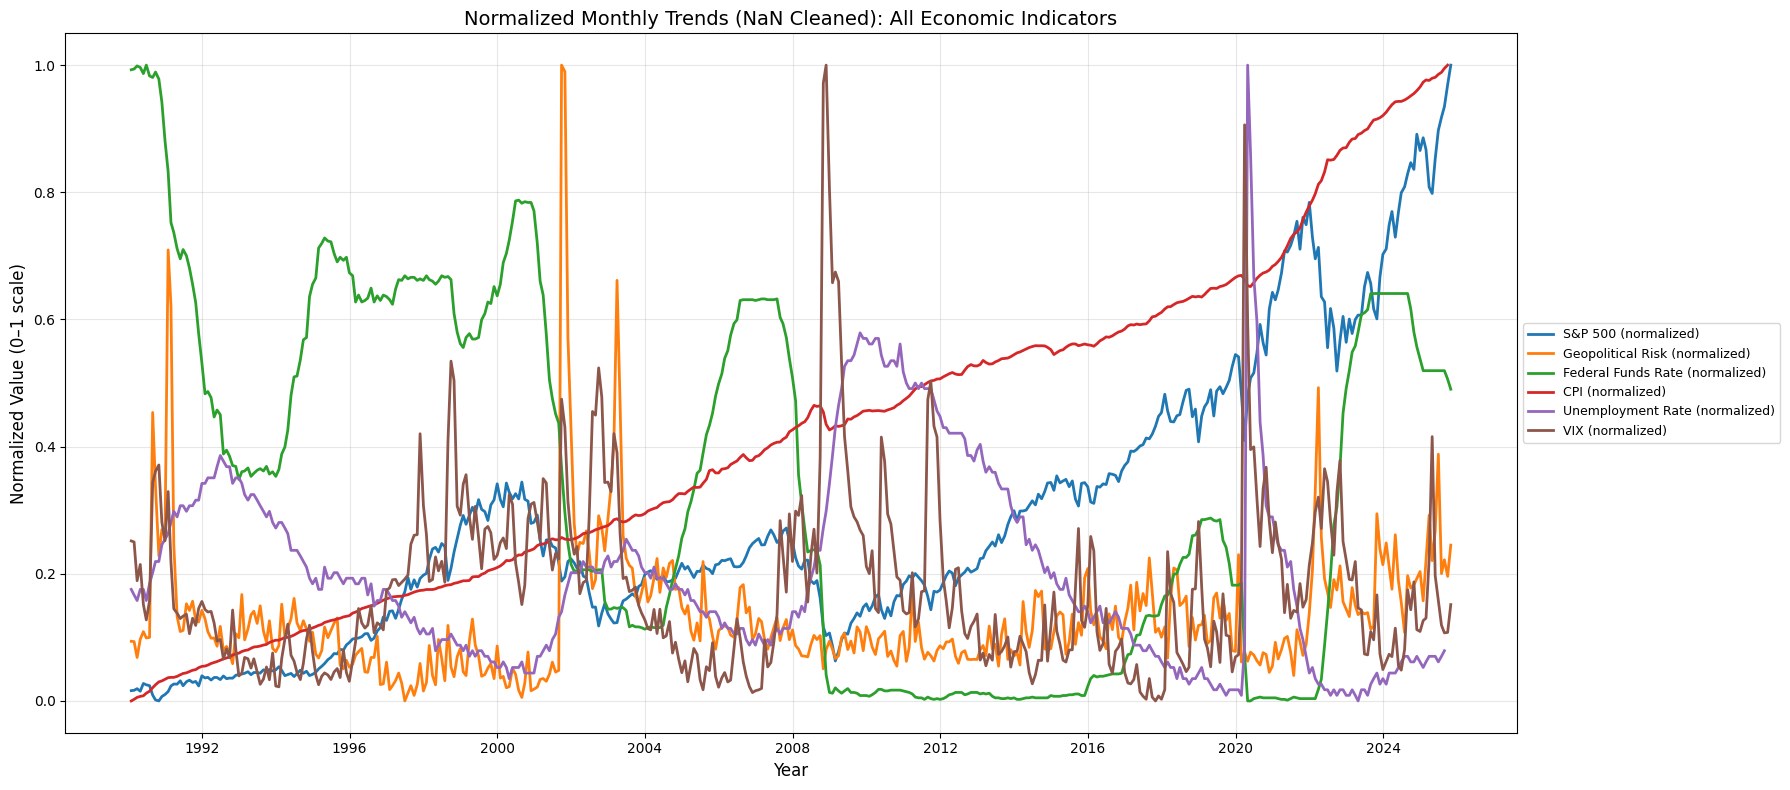

In [38]:
# Normalized graph for NaN cleaned dataset
normalized_df_clean = merged_monthly_df_clean.copy()

# Normalize all numeric columns
original_cols = ['SP500 Index Value ($)', 'GPRC_USA', 'FEDFUNDS', 'CPI', 'UNEMPLOYMENT RATE', 'VIX']

# Normalize original columns
for col in original_cols:
    if col in normalized_df_clean.columns:
        normalized_df_clean[col + '_norm'] = (
            normalized_df_clean[col] - normalized_df_clean[col].min()
        ) / (normalized_df_clean[col].max() - normalized_df_clean[col].min())

plt.figure(figsize=(18,8))
# Plot original normalized values
plt.plot(normalized_df_clean.index, normalized_df_clean['SP500 Index Value ($)_norm'], label='S&P 500 (normalized)', linewidth=2)
plt.plot(normalized_df_clean.index, normalized_df_clean['GPRC_USA_norm'], label='Geopolitical Risk (normalized)', linewidth=2)
plt.plot(normalized_df_clean.index, normalized_df_clean['FEDFUNDS_norm'], label='Federal Funds Rate (normalized)', linewidth=2)
if 'CPI_norm' in normalized_df_clean.columns:
    plt.plot(normalized_df_clean.index, normalized_df_clean['CPI_norm'], label='CPI (normalized)', linewidth=2)
if 'UNEMPLOYMENT RATE_norm' in normalized_df_clean.columns:
    plt.plot(normalized_df_clean.index, normalized_df_clean['UNEMPLOYMENT RATE_norm'], label='Unemployment Rate (normalized)', linewidth=2)
if 'VIX_norm' in normalized_df_clean.columns:
    plt.plot(normalized_df_clean.index, normalized_df_clean['VIX_norm'], label='VIX (normalized)', linewidth=2)

plt.title("Normalized Monthly Trends (NaN Cleaned): All Economic Indicators", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Normalized Value (0–1 scale)", fontsize=12)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [39]:
# Add CHANGE RATE columns for cleaned datasets (merged_monthly_df_clean and merged_yearly_df_clean)
import numpy as np

# Function to add CHANGE RATE columns next to each numeric column
def add_change_rate_columns(df, exclude_cols=None):
    if exclude_cols is None:
        exclude_cols = []
    df_with_changes = df.copy()
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col not in exclude_cols]
    new_columns = []
    for col in df.columns:
        new_columns.append(col)
        if col in numeric_cols:
            if 'SP500' in col:
                change_col_name = 'SP500 CHANGE RATE'
            elif 'GPRC_USA' in col or 'GPRC' in col:
                change_col_name = 'GPRC CHANGE RATE'
            elif 'FEDFUNDS' in col:
                change_col_name = 'FEDFUNDS CHANGE RATE'
            elif 'CPI' in col and 'CHANGE' not in col:
                change_col_name = 'CPI CHANGE RATE'
            elif 'UNEMPLOYMENT' in col or 'UNRATE' in col:
                change_col_name = 'UNEMPLOYMENT RATE CHANGE RATE'
            elif 'VIX' in col and 'CHANGE' not in col:
                change_col_name = 'VIX CHANGE RATE'
            elif 'GDP' in col:
                change_col_name = 'GDP CHANGE RATE'
            else:
                change_col_name = col.replace(' Index Value ($)', ' CHANGE RATE').replace(' ($)', ' CHANGE RATE').replace('_', ' ').title().replace(' ', ' ') + ' CHANGE RATE'
            df_with_changes[change_col_name] = df[col].pct_change(fill_method=None) * 100
            new_columns.append(change_col_name)
    df_with_changes = df_with_changes[new_columns]
    return df_with_changes

# Apply to cleaned datasets
merged_monthly_df_clean_with_changes = add_change_rate_columns(merged_monthly_df_clean, exclude_cols=['date_month'])
merged_yearly_df_clean_with_changes = add_change_rate_columns(merged_yearly_df_clean, exclude_cols=['Year'])

# To view the datasets, uncomment the following:
merged_monthly_df_clean_with_changes
#merged_yearly_df_clean_with_changes


,SP500 Index Value ($),SP500 CHANGE RATE,date_month,GPRC_USA,GPRC CHANGE RATE,FEDFUNDS,FEDFUNDS CHANGE RATE,CPI,CPI CHANGE RATE,UNEMPLOYMENT RATE,UNEMPLOYMENT RATE CHANGE RATE,VIX,VIX CHANGE RATE
Date,,,,,,,,,,,,,
1990-01-31,833.19,NaN,1990.01,1.921422,NaN,8.23,NaN,127.500,NaN,5.4,NaN,23.347273,NaN
1990-02-28,836.37,0.381666,1990.02,1.915435,-0.311613,8.24,0.121507,128.000,0.392157,5.3,-1.851852,23.262632,-0.362531
1990-03-30,851.99,1.867594,1990.03,1.604008,-16.258812,8.28,0.485437,128.600,0.468750,5.2,-1.886792,20.062273,-13.757510
1990-04-30,827.80,-2.839235,1990.04,1.961507,22.287848,8.26,-0.241546,128.900,0.233281,5.4,3.846154,21.403500,6.685321
1990-05-31,901.85,8.945397,1990.05,2.111446,7.644081,8.18,-0.968523,129.100,0.155159,5.4,0.000000,18.097727,-15.445010
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-30,6204.95,4.603960,2025.06,5.592269,36.806012,4.33,0.000000,321.500,0.286980,4.1,-2.380952,18.403333,-10.062125
2025-07-31,6329.83,2.012587,2025.07,3.250141,-41.881531,4.33,0.000000,322.132,0.196579,4.2,2.439024,16.381304,-10.987298
2025-08-29,6432.04,1.614735,2025.08,3.521580,8.351608,4.33,0.000000,323.364,0.382452,4.3,2.380952,15.750000,-3.853810


## Generating Summary Statistics

In [40]:
merged_monthly_summary = merged_monthly_df.drop(columns=['date_month']).describe().T
merged_monthly_summary['missing'] = merged_monthly_df.drop(columns=['date_month']).isna().sum()
merged_monthly_summary = merged_monthly_summary.round(3)
merged_yearly_summary = merged_yearly_df.drop(columns=['Year']).describe().T
merged_yearly_summary['missing'] = merged_yearly_df.drop(columns=['Year']).isna().sum()
merged_yearly_summary = merged_yearly_summary.round(3)

merged_monthly_with_changes_summary = merged_monthly_df_with_changes.drop(columns=['date_month']).describe().T
merged_monthly_with_changes_summary['missing'] = merged_monthly_df_with_changes.drop(columns=['date_month']).isna().sum()
merged_monthly_with_changes_summary = merged_monthly_with_changes_summary.round(3)
merged_yearly_with_changes_summary = merged_yearly_df_with_changes.drop(columns=['Year']).describe().T
merged_yearly_with_changes_summary['missing'] = merged_yearly_df_with_changes.drop(columns=['Year']).isna().sum()
merged_yearly_with_changes_summary = merged_yearly_with_changes_summary.round(3)

merged_monthly_cleaned_summary = merged_monthly_df_clean.drop(columns=['date_month']).describe().T
merged_monthly_cleaned_summary['missing'] = merged_monthly_df_clean.drop(columns=['date_month']).isna().sum()
merged_monthly_cleaned_summary = merged_monthly_cleaned_summary.round(3)
merged_yearly_cleaned_summary = merged_yearly_df_clean.drop(columns=['Year']).describe().T
merged_yearly_cleaned_summary['missing'] = merged_yearly_df_clean.drop(columns=['Year']).isna().sum()
merged_yearly_cleaned_summary = merged_yearly_cleaned_summary.round(3)

merged_monthly_with_changes_cleaned_summary = merged_monthly_df_clean_with_changes.drop(columns=['date_month']).describe().T
merged_monthly_with_changes_cleaned_summary['missing'] = merged_monthly_df_clean_with_changes.drop(columns=['date_month']).isna().sum()
merged_monthly_with_changes_cleaned_summary = merged_monthly_with_changes_cleaned_summary.round(3)
merged_yearly_with_changes_cleaned_summary = merged_yearly_df_clean_with_changes.drop(columns=['Year']).describe().T
merged_yearly_with_changes_cleaned_summary['missing'] = merged_yearly_df_clean_with_changes.drop(columns=['Year']).isna().sum()
merged_yearly_with_changes_cleaned_summary = merged_yearly_with_changes_cleaned_summary.round(3)


# To view the datasets, uncomment the following:
#merged_monthly_summary
#merged_monthly_with_changes_summary
#merged_monthly_cleaned_summary
#merged_monthly_with_changes_cleaned_summary
#merged_yearly_summary
#merged_yearly_with_changes_summary
#merged_yearly_cleaned_summary
merged_yearly_with_changes_cleaned_summary


,count,mean,std,min,25%,50%,75%,max,missing
SP500 Index Value ($),35.0,2.396455e+03,1.223991e+03,8.219290e+02,1.684607e+03,2.109470e+03,2.811068e+03,5.612773e+03,0
SP500 CHANGE RATE,34.0,6.645000e+00,1.304300e+01,-2.171200e+01,1.982000e+00,7.137000e+00,1.571000e+01,2.695300e+01,1
GPRC_USA,35.0,2.343000e+00,8.170000e-01,1.054000e+00,1.820000e+00,2.195000e+00,2.725000e+00,4.350000e+00,0
GPRC CHANGE RATE,34.0,6.799000e+00,5.212200e+01,-4.664600e+01,-1.648800e+01,-1.091000e+00,1.089000e+01,2.677030e+02,1
US GDP inflation adjusted ($),35.0,1.457235e+13,6.363853e+12,5.963144e+12,9.346994e+12,1.447423e+13,1.854997e+13,2.918489e+13,0
GDP CHANGE RATE,34.0,4.808000e+00,2.387000e+00,-1.976000e+00,3.867000e+00,4.831000e+00,6.175000e+00,1.089800e+01,1
FEDFUNDS,35.0,2.841000e+00,2.349000e+00,8.000000e-02,3.850000e-01,2.158000e+00,5.022000e+00,8.099000e+00,0
FEDFUNDS CHANGE RATE,34.0,7.202000e+01,3.488500e+02,-9.169900e+01,-3.170700e+01,1.740000e+00,3.898800e+01,2.004167e+03,1
CPI,35.0,2.070620e+02,4.946300e+01,1.306580e+02,1.647960e+02,2.073440e+02,2.385040e+02,3.136980e+02,0
CPI CHANGE RATE,34.0,2.619000e+00,1.429000e+00,-3.200000e-01,1.681000e+00,2.632000e+00,3.115000e+00,7.993000e+00,1


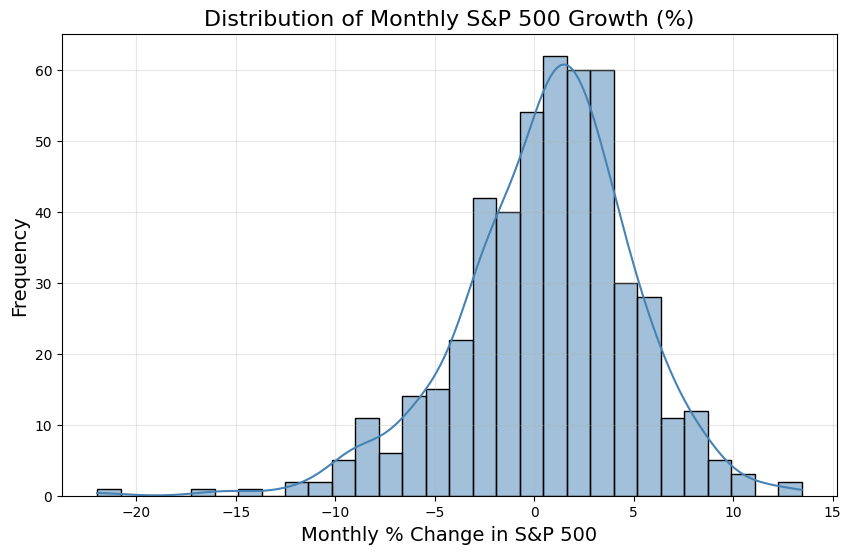

In [41]:
import seaborn as sns

sp500_changes = merged_monthly_df_with_changes['SP500 CHANGE RATE'].dropna()

plt.figure(figsize=(10, 6))
sns.histplot(sp500_changes, bins=30, kde=True, color='steelblue')

plt.title("Distribution of Monthly S&P 500 Growth (%)", fontsize=16)
plt.xlabel("Monthly % Change in S&P 500", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.grid(alpha=0.3)
plt.show()

## Preliminary Analysis (EDA)

<Axes: xlabel='Date'>

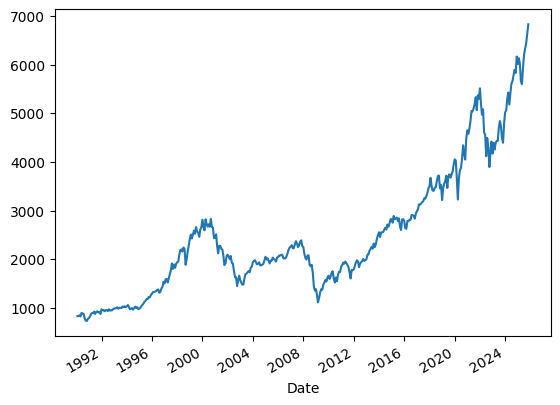

In [42]:
merged_monthly_df_clean_with_changes['SP500 Index Value ($)'].plot()

In [43]:
s = merged_monthly_df_clean_with_changes['SP500 CHANGE RATE'].dropna()
s.describe(percentiles=[.01,.05,.25,.5,.75,.95,.99])

count    429.000000
mean       0.583168
std        4.260488
min      -16.094929
1%       -10.899925
5%        -6.973165
25%       -1.971120
50%        1.042705
75%        3.195388
95%        7.029409
99%        9.134156
max       13.443099
Name: SP500 CHANGE RATE, dtype: float64

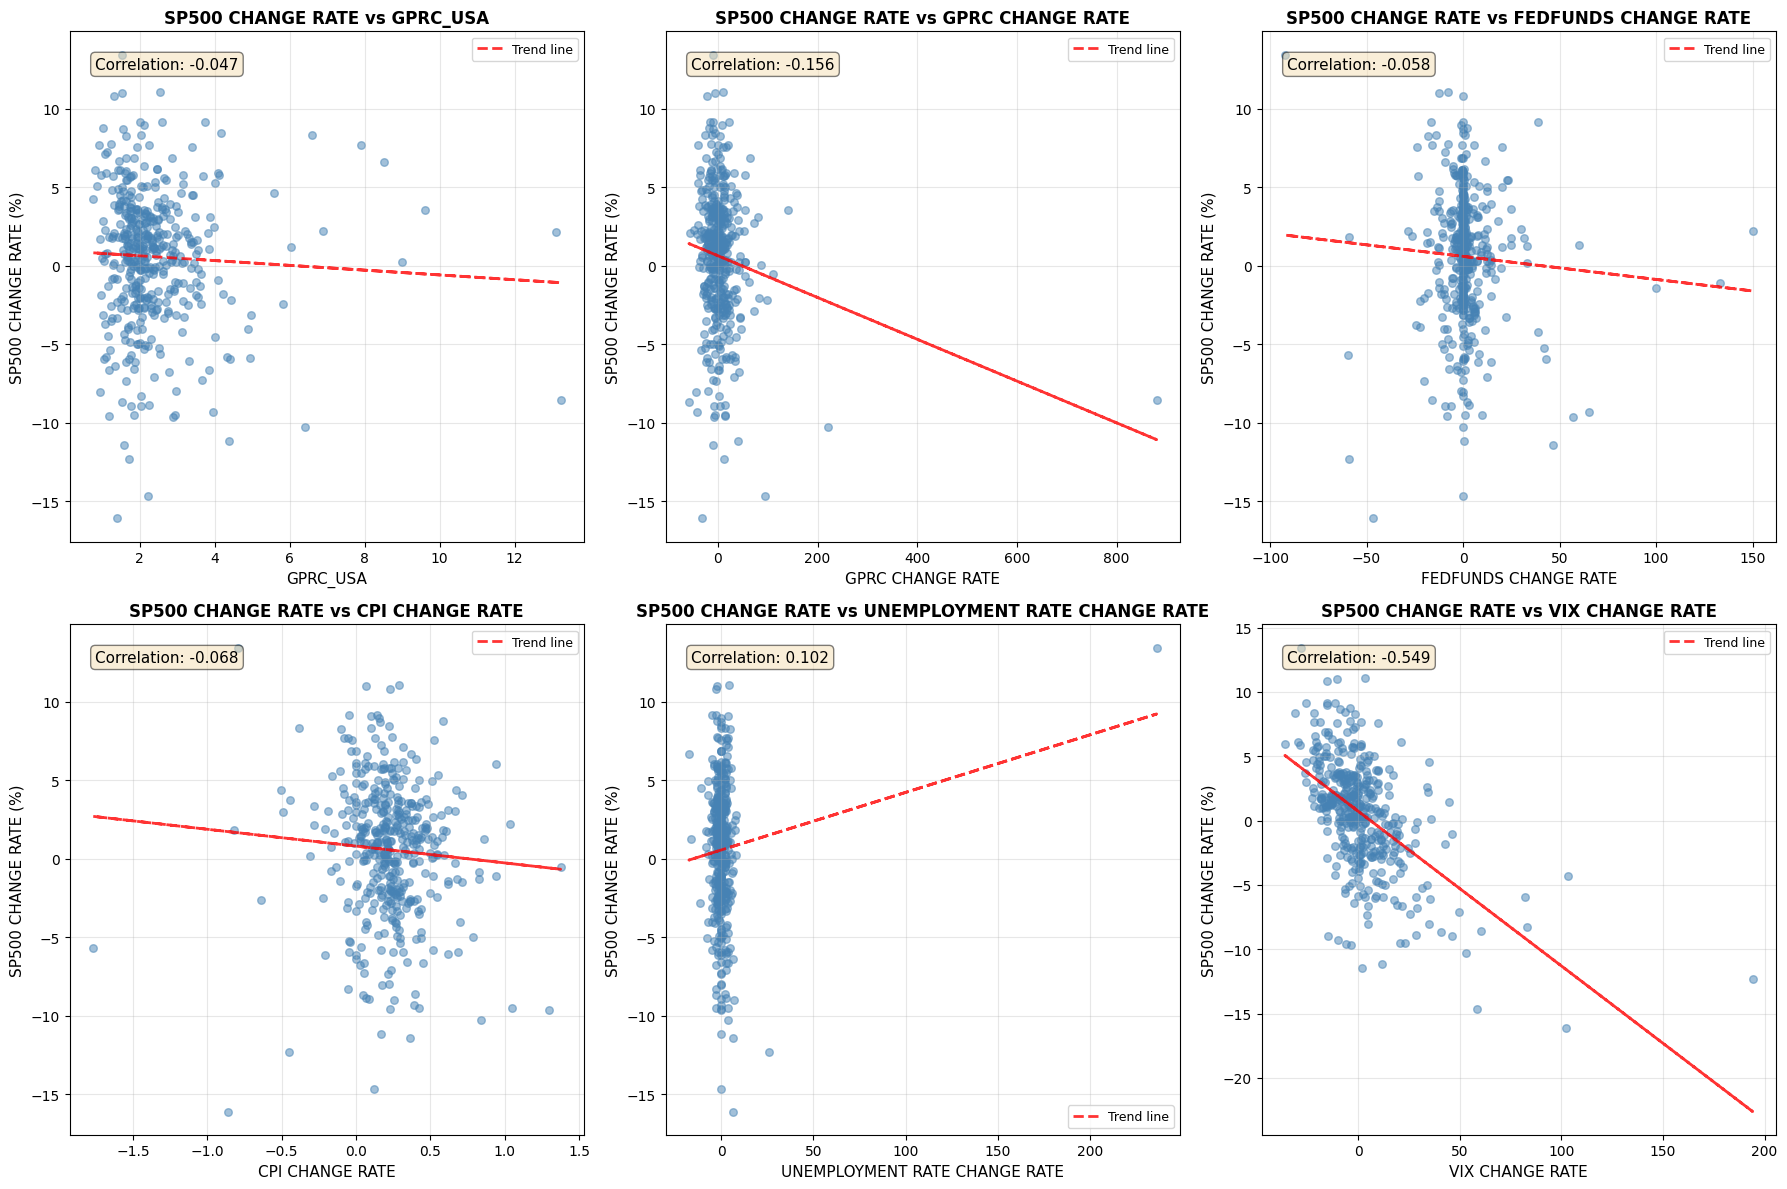

Correlation coefficients with SP500 CHANGE RATE:
SP500 CHANGE RATE                1.000000
FEDFUNDS CHANGE RATE            -0.058215
CPI CHANGE RATE                 -0.067090
UNEMPLOYMENT RATE CHANGE RATE    0.102422
VIX CHANGE RATE                 -0.547795
GPRC CHANGE RATE                -0.155866
Name: SP500 CHANGE RATE, dtype: float64

Additional: Correlation with GPRC_USA (level):
GPRC_USA: -0.044973


In [44]:
# ===== Scatter Plots: SP500 CHANGE RATE vs Economic Indicators =====
# Visualize relationships before computing correlations

cols = ['SP500 CHANGE RATE',
        'FEDFUNDS CHANGE RATE',
        'CPI CHANGE RATE',
        'UNEMPLOYMENT RATE CHANGE RATE',
        'VIX CHANGE RATE',
        'GPRC CHANGE RATE']

# Add GPRC_USA (level) for comparison
df_plot = merged_monthly_df_clean_with_changes[cols + ['GPRC_USA']].dropna()

# Create scatter plots in a 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Include both CHANGE RATE variables and GPRC_USA (level)
predictors = ['GPRC_USA', 'GPRC CHANGE RATE', 'FEDFUNDS CHANGE RATE', 
              'CPI CHANGE RATE', 'UNEMPLOYMENT RATE CHANGE RATE', 'VIX CHANGE RATE']

for i, pred in enumerate(predictors):
    ax = axes[i]
    x = df_plot[pred]
    y = df_plot['SP500 CHANGE RATE']
    
    # Scatter plot
    ax.scatter(x, y, alpha=0.5, s=30, color='steelblue')
    
    # Add correlation coefficient as text
    corr = x.corr(y)
    ax.text(0.05, 0.95, f'Correlation: {corr:.3f}', 
            transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Add trend line
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    ax.plot(x, p(x), "r--", alpha=0.8, linewidth=2, label='Trend line')
    
    ax.set_xlabel(pred, fontsize=11)
    ax.set_ylabel('SP500 CHANGE RATE (%)', fontsize=11)
    ax.set_title(f'SP500 CHANGE RATE vs {pred}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ===== Correlation Analysis =====
print("Correlation coefficients with SP500 CHANGE RATE:")
print(merged_monthly_df_clean_with_changes[cols].corr()['SP500 CHANGE RATE'])
print("\nAdditional: Correlation with GPRC_USA (level):")
print(f"GPRC_USA: {merged_monthly_df_clean_with_changes['GPRC_USA'].corr(merged_monthly_df_clean_with_changes['SP500 CHANGE RATE']):.6f}")

Text(0.5, 1.0, 'S&P 500 Index Adjusted and Unemployment Rate Since 1990')

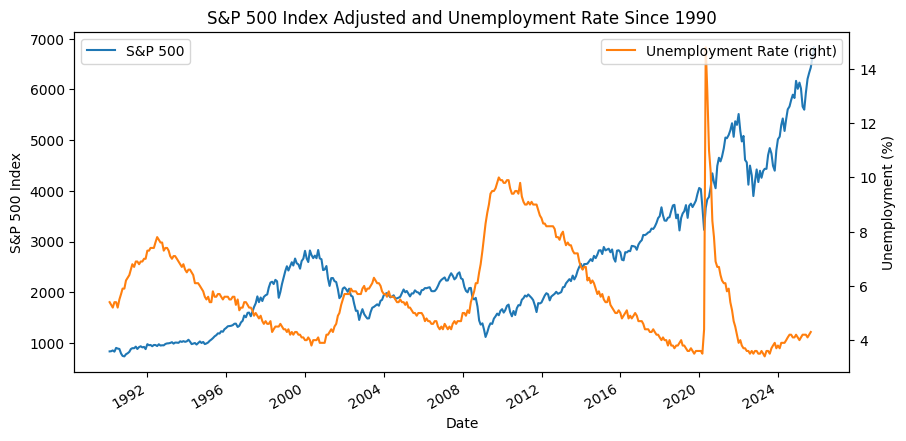

In [45]:
# Putting unemploymenr rate and S&P500 together, we can see that their trends
# are opposite 
ax = merged_monthly_df_clean_with_changes['SP500 Index Value ($)'].plot(
    figsize=(10, 5),
    label='S&P 500',
    color='C0'
)

merged_monthly_df_clean_with_changes['UNEMPLOYMENT RATE'].plot(
    ax=ax,
    secondary_y=True,
    label='Unemployment Rate',
    color='C1'
)

ax.set_ylabel('S&P 500 Index')
ax.right_ax.set_ylabel('Unemployment (%)')

ax.legend(loc='upper left')
ax.right_ax.legend(loc='upper right')
ax.set_title('S&P 500 Index Adjusted and Unemployment Rate Since 1990')


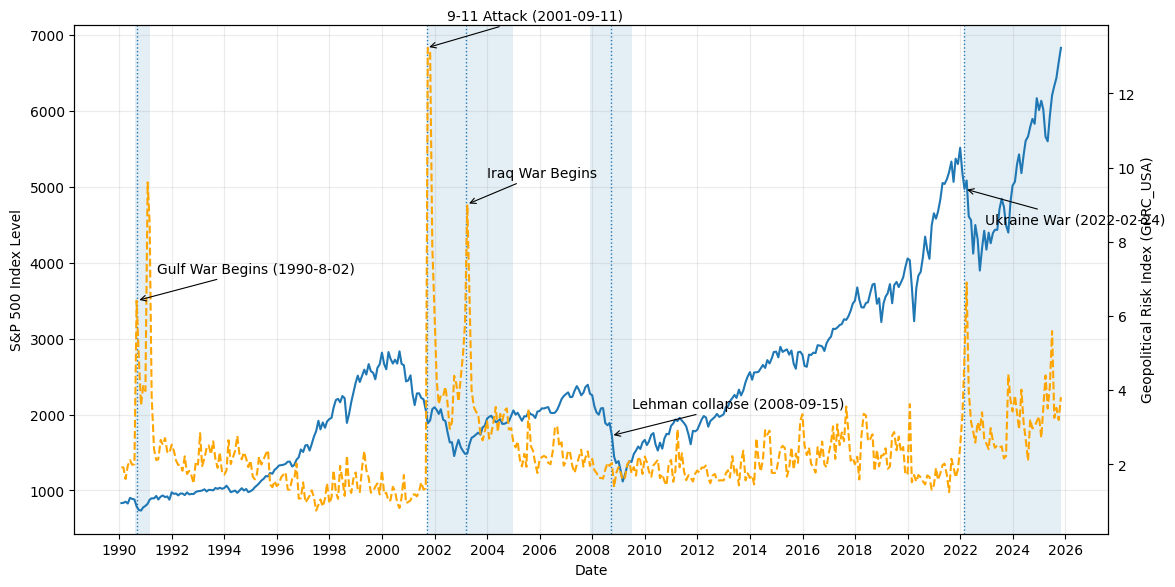

In [46]:
import matplotlib.dates as mdates

df = merged_monthly_df_clean_with_changes.copy()

# Ensure datetime index
df.index = pd.to_datetime(df.index)

fig, ax = plt.subplots(figsize=(12, 6))

# Left axis: S&P 500 level
sp_line = ax.plot(df.index, df['SP500 Index Value ($)'], label='S&P 500 (level)')

ax.set_ylabel('S&P 500 Index Level')
ax.set_xlabel('Date')

# Right axis: Geopolitical Risk (GPRC_USA)
ax2 = ax.twinx()
gprc_line = ax2.plot(df.index, df['GPRC_USA'], linestyle='--', label='GPRC (USA)',color='orange')
ax2.set_ylabel('Geopolitical Risk Index (GPRC_USA)')

# --- Event windows (shaded) ---
# Gulf War: Aug 1990 - Mar 1991
ax.axvspan(pd.Timestamp('1990-08-02'), pd.Timestamp('1991-2-28'), alpha=0.12, label='1990-1991 Gulf War')
#911 Panic: Sep 2001 - Jun 2003
ax.axvspan(pd.Timestamp('2001-09-11'), pd.Timestamp('2005-01-01'), alpha=0.12, label='2001 911 Attack Panic Window')
# NBER Great Recession window (approx): Dec 2007–Jun 2009
ax.axvspan(pd.Timestamp('2007-12-01'), pd.Timestamp('2009-06-30'), alpha=0.12, label='2008 Financial Crisis window')
# COVID recession (approx): Feb–Apr 2020
#ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-04-30'), alpha=0.12, label='2020 COVID recession window')
# Ukraine War: Feb 2022 - present
ax.axvspan(pd.Timestamp('2022-02-24'), pd.Timestamp('2025-10-31'), alpha=0.12, label='2022 Ukraine War')

# Gulf war
ax.axvline(pd.Timestamp('1990-08-31'),linestyle=':', linewidth=1)
ax2.annotate('Gulf War Begins (1990-8-02)', xy=(pd.Timestamp('1990-08-31'), 
             df['GPRC_USA'].loc['1990-08-31']),
            xytext=(15, 20), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', lw=0.8))
# 911 Attack
ax.axvline(pd.Timestamp('2001-09-11'),linestyle=':', linewidth=1)
ax2.annotate('9-11 Attack (2001-09-11)', xy=(pd.Timestamp('2001-09-11'), 
             df['GPRC_USA'].loc['2001-09-28']),
            xytext=(15, 20), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', lw=0.8))
# Iraq Attack
ax.axvline(pd.Timestamp('2003-03-20'),linestyle=':', linewidth=1)
ax2.annotate('Iraq War Begins', xy=(pd.Timestamp('2003-03-20'), 
             df['GPRC_USA'].loc['2003-03-31']),
            xytext=(15, 20), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', lw=0.8))
# Lehman Brothers collapse
ax.axvline(pd.Timestamp('2008-09-15'), linestyle=':', linewidth=1)
ax.annotate('Lehman collapse (2008-09-15)', xy=(pd.Timestamp('2008-09-15'), 
             df['SP500 Index Value ($)'].loc['2008-09-30']),
            xytext=(15, 20), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', lw=0.8))

# WHO declares COVID-19 pandemic
#ax.axvline(pd.Timestamp('2020-03-11'), linestyle=':', linewidth=1)
# pick a y close to the series around that date to avoid None
#y_2020 = df['SP500 Index Value ($)'].loc['2020-03-31']
#ax.annotate('WHO pandemic declared (2020-03-11)',
            #xy=(pd.Timestamp('2020-03-11'), y_2020),
            #xytext=(15, -25), textcoords='offset points',
            #arrowprops=dict(arrowstyle='->', lw=0.8))
#Russia Declare War on Ukraine
ax.axvline(pd.Timestamp('2022-02-24'), linestyle=':', linewidth=1)
y_2022 = df['SP500 Index Value ($)'].loc['2022-02-28']
ax.annotate('Ukraine War (2022-02-24)',
            xy=(pd.Timestamp('2022-02-28'), y_2022),
            xytext=(15, -25), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', lw=0.8))
# Formatting: yearly ticks
ax.xaxis.set_major_locator(mdates.YearLocator(base=2))  # every 2 years
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Build one combined legend
#lines = sp_line + gprc_line
#labels = [l.get_label() for l in lines]
#legend1 = ax.legend(lines, labels, loc='upper left')
#legend2 = ax.legend(loc='upper right')  # picks up the span labels
#ax.add_artist(legend1)

ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

EVENT-BASED ANALYSIS: Short-Term Market Reactions

Summary Statistics for Major Events:
                   Event         Type  Event Month Return (%)  Avg Return Before (%)  Avg Return After (%)  Min Return (%)  Min Return Month  GPR at Event  GPR Change at Event (%)   Max GPR
             9/11 Attack Geopolitical               -6.410885              -1.135643             -0.302719       -8.584022                 1      1.349414                 2.430174 13.229010
Lehman Brothers Collapse    Financial                1.624411              -3.595913             -8.214433      -16.094929                 2      1.955354                -4.041881  2.037716
             Ukraine War Geopolitical               -6.049055               2.918975             -2.115999       -9.633333                 5      3.315881                33.791181  6.899374
                Gulf War Geopolitical               -0.904367               1.561177             -0.942579      -10.256760                 1      1.9984

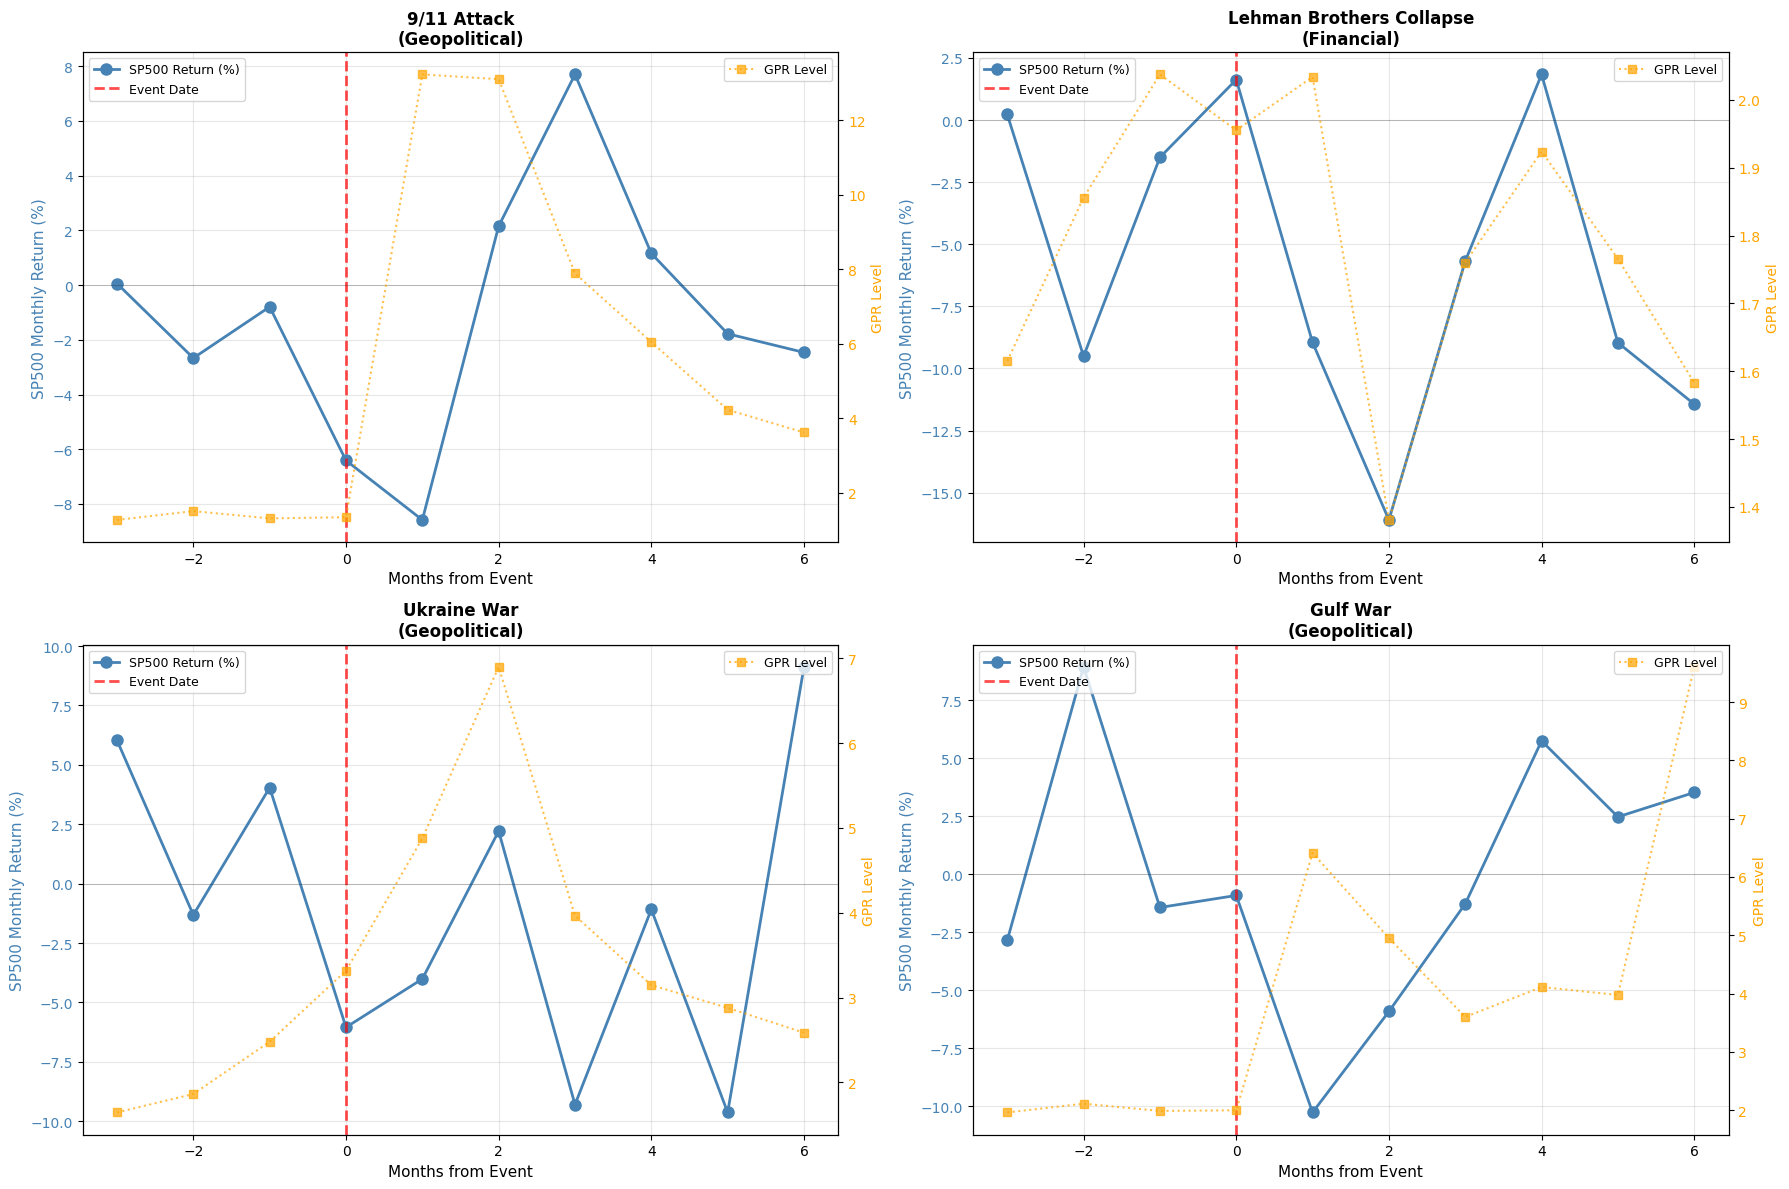


CUMULATIVE RETURN ANALYSIS

9/11 Attack:
  Maximum cumulative loss: -17.34%
  Event month return: -6.41%
  GPR at event: 1.35
  GPR change at event: 2.43%
  Recovery time: Not recovered within 6 months

Lehman Brothers Collapse:
  Maximum cumulative loss: -46.29%
  Event month return: 1.62%
  GPR at event: 1.96
  GPR change at event: -4.04%
  Recovery time: 0 months

Ukraine War:
  Maximum cumulative loss: -18.65%
  Event month return: -6.05%
  GPR at event: 3.32
  GPR change at event: 33.79%
  Recovery time: Not recovered within 6 months

Gulf War:
  Maximum cumulative loss: -13.79%
  Event month return: -0.90%
  GPR at event: 2.00
  GPR change at event: 0.55%
  Recovery time: Not recovered within 6 months

EVENT IMPACT COMPARISON

Baseline (excluding event months):
  Mean return: 0.62%
  Std return: 4.25%
  Min return: -16.09%

Event months only:
  Mean return: -2.93%
  Std return: 3.95%
  Min return: -6.41%

T-test (event months vs baseline):
  t-statistic: nan
  p-value: nan
  → N

In [59]:
## Event-Based Analysis: Short-Term Stock Market Reactions to Major Geopolitical and Financial Crises

# ===== Event Window Analysis: Major Crises Impact on S&P 500 =====
# Analyze how major events (9/11, Lehman Brothers, Ukraine War) affected short-term stock returns

df = merged_monthly_df_clean_with_changes.copy()
df.index = pd.to_datetime(df.index)

# Define major events with event dates and analysis windows
events = {
    '9/11 Attack': {
        'date': pd.Timestamp('2001-09-11'),
        'window_before': 3,  # months before
        'window_after': 6,   # months after
        'type': 'Geopolitical'
    },
    'Lehman Brothers Collapse': {
        'date': pd.Timestamp('2008-09-15'),
        'window_before': 3,
        'window_after': 6,
        'type': 'Financial'
    },
    'Ukraine War': {
        'date': pd.Timestamp('2022-02-24'),
        'window_before': 3,
        'window_after': 6,
        'type': 'Geopolitical'
    },
    'Gulf War': {
        'date': pd.Timestamp('1990-08-02'),
        'window_before': 3,
        'window_after': 6,
        'type': 'Geopolitical'
    }
}

# Function to extract event window data
def get_event_window(df, event_date, months_before, months_after):
    """Extract data for months around an event"""
    event_month = event_date.to_period('M').to_timestamp()
    
    # Get the month index closest to event date
    closest_idx = df.index[df.index <= event_month]
    if len(closest_idx) == 0:
        return None
    
    event_idx = closest_idx[-1]
    event_pos = df.index.get_loc(event_idx)
    
    # Extract window
    start_pos = max(0, event_pos - months_before)
    end_pos = min(len(df), event_pos + months_after + 1)
    
    window_data = df.iloc[start_pos:end_pos].copy()
    window_data['months_from_event'] = range(-months_before, len(window_data) - months_before)
    
    return window_data, event_pos

# Collect event statistics
event_results = []

for event_name, event_info in events.items():
    result = get_event_window(df, event_info['date'], 
                             event_info['window_before'], 
                             event_info['window_after'])
    
    if result is None:
        continue
    
    window_data, event_pos = result
    
    # Calculate statistics
    event_month_return = window_data.iloc[event_info['window_before']]['SP500 CHANGE RATE'] if len(window_data) > event_info['window_before'] else None
    before_avg = window_data[window_data['months_from_event'] < 0]['SP500 CHANGE RATE'].mean()
    after_avg = window_data[window_data['months_from_event'] > 0]['SP500 CHANGE RATE'].mean()
    min_return = window_data['SP500 CHANGE RATE'].min()
    min_return_month = window_data.loc[window_data['SP500 CHANGE RATE'].idxmin(), 'months_from_event']
    
    # GPR changes
    event_gpr = window_data.iloc[event_info['window_before']]['GPRC_USA'] if len(window_data) > event_info['window_before'] else None
    gpr_change = window_data.iloc[event_info['window_before']]['GPRC CHANGE RATE'] if len(window_data) > event_info['window_before'] else None
    max_gpr = window_data['GPRC_USA'].max()
    
    event_results.append({
        'Event': event_name,
        'Type': event_info['type'],
        'Event Month Return (%)': event_month_return,
        'Avg Return Before (%)': before_avg,
        'Avg Return After (%)': after_avg,
        'Min Return (%)': min_return,
        'Min Return Month': min_return_month,
        'GPR at Event': event_gpr,
        'GPR Change at Event (%)': gpr_change,
        'Max GPR': max_gpr
    })

event_summary = pd.DataFrame(event_results)
print("=" * 80)
print("EVENT-BASED ANALYSIS: Short-Term Market Reactions")
print("=" * 80)
print("\nSummary Statistics for Major Events:")
print(event_summary.to_string(index=False))

# ===== Visualization: Event Windows =====
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, (event_name, event_info) in enumerate(events.items()):
    if idx >= 4:
        break
    
    result = get_event_window(df, event_info['date'], 
                             event_info['window_before'], 
                             event_info['window_after'])
    
    if result is None:
        continue
    
    window_data, _ = result
    ax = axes[idx]
    
    # Plot SP500 returns
    ax.plot(window_data['months_from_event'], window_data['SP500 CHANGE RATE'], 
            marker='o', linewidth=2, markersize=8, label='SP500 Return (%)', color='steelblue')
    
    # Mark event date
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Event Date')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
    
    # Add GPR on secondary axis
    ax2 = ax.twinx()
    ax2.plot(window_data['months_from_event'], window_data['GPRC_USA'], 
             marker='s', linewidth=1.5, markersize=6, label='GPR Level', 
             color='orange', alpha=0.7, linestyle=':')
    ax2.set_ylabel('GPR Level', color='orange', fontsize=10)
    ax2.tick_params(axis='y', labelcolor='orange')
    
    ax.set_xlabel('Months from Event', fontsize=11)
    ax.set_ylabel('SP500 Monthly Return (%)', fontsize=11, color='steelblue')
    ax.tick_params(axis='y', labelcolor='steelblue')
    ax.set_title(f'{event_name}\n({event_info["type"]})', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=9)
    ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

# ===== Detailed Analysis: Cumulative Returns Around Events =====
print("\n" + "=" * 80)
print("CUMULATIVE RETURN ANALYSIS")
print("=" * 80)

for event_name, event_info in events.items():
    result = get_event_window(df, event_info['date'], 
                             event_info['window_before'], 
                             event_info['window_after'])
    
    if result is None:
        continue
    
    window_data, _ = result
    
    # Calculate cumulative returns
    window_data['cumulative_return'] = (1 + window_data['SP500 CHANGE RATE'] / 100).cumprod() - 1
    cumulative_loss = window_data['cumulative_return'].min() * 100
    
    # Find recovery period (months to return to pre-event level)
    pre_event_level = window_data[window_data['months_from_event'] < 0]['cumulative_return'].iloc[-1] if len(window_data[window_data['months_from_event'] < 0]) > 0 else 0
    recovery_data = window_data[window_data['months_from_event'] >= 0].copy()
    recovery_data['recovered'] = recovery_data['cumulative_return'] >= pre_event_level
    
    recovery_months = None
    if recovery_data['recovered'].any():
        recovery_months = recovery_data[recovery_data['recovered']]['months_from_event'].iloc[0]
    
    print(f"\n{event_name}:")
    print(f"  Maximum cumulative loss: {cumulative_loss:.2f}%")
    print(f"  Event month return: {window_data.iloc[event_info['window_before']]['SP500 CHANGE RATE']:.2f}%")
    print(f"  GPR at event: {window_data.iloc[event_info['window_before']]['GPRC_USA']:.2f}")
    print(f"  GPR change at event: {window_data.iloc[event_info['window_before']]['GPRC CHANGE RATE']:.2f}%")
    if recovery_months is not None:
        print(f"  Recovery time: {recovery_months} months")
    else:
        print(f"  Recovery time: Not recovered within {event_info['window_after']} months")

# ===== Comparison: Event vs Normal Periods =====
print("\n" + "=" * 80)
print("EVENT IMPACT COMPARISON")
print("=" * 80)

# Calculate baseline statistics (excluding event months)
all_event_months = []
for event_name, event_info in events.items():
    result = get_event_window(df, event_info['date'], 0, 0)
    if result:
        window_data, _ = result
        if len(window_data) > 0:
            event_month = window_data.index[0]
            all_event_months.append(event_month)

baseline_returns = df[~df.index.isin(all_event_months)]['SP500 CHANGE RATE']
event_month_returns = df[df.index.isin(all_event_months)]['SP500 CHANGE RATE']

print(f"\nBaseline (excluding event months):")
print(f"  Mean return: {baseline_returns.mean():.2f}%")
print(f"  Std return: {baseline_returns.std():.2f}%")
print(f"  Min return: {baseline_returns.min():.2f}%")

print(f"\nEvent months only:")
print(f"  Mean return: {event_month_returns.mean():.2f}%")
print(f"  Std return: {event_month_returns.std():.2f}%")
print(f"  Min return: {event_month_returns.min():.2f}%")

# Statistical test
from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(baseline_returns, event_month_returns)
print(f"\nT-test (event months vs baseline):")
print(f"  t-statistic: {t_stat:.3f}")
print(f"  p-value: {p_value:.4f}")
if p_value < 0.05:
    print("  → Event months show significantly different returns (p < 0.05)")
else:
    print("  → No significant difference (p >= 0.05)")



## Preliminary Question 1: Which Major Financial Feature(s) affect S&P 500?
## 1. Stationarity Testing

Before running any regression, we test whether the variables are **stationary**, which is required for valid inference in time-series analysis.

### **Tests Applied**
- **ADF (Augmented Dickey–Fuller)**  
  - Null: series is **non-stationary**
- **KPSS (Kwiatkowski–Phillips–Schmidt–Shin)**  
  - Null: series is **stationary**
- **Ljung–Box**  
  - Tests autocorrelation in returns

### **Results**
- **S&P 500 Index Level**
  - ADF: fail to reject non-stationarity  
  - KPSS: reject stationarity  
  ➝ **Index level is non-stationary** (typical for price series)

- **S&P 500 Return (Rate of Change)**
  - ADF: reject non-stationarity  
  - KPSS: fail to reject stationarity  
  - Ljung–Box: no autocorrelation  
  ➝ **Returns are stationary and suitable for regression**

## **Final Conclusion**

- The **S&P 500 index level is non-stationary**, so it cannot be used for inference.  
- The **rate of change (return) is stationary**, making it valid for regression.  

In [47]:
#Hypothesis Test, it's clear that S&P 500 adjusted for inflation is not
#staionary, what about the rate of change?
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
df = merged_monthly_df_clean_with_changes.copy()
s = df['SP500 Index Value ($)'].dropna()
r = df['SP500 CHANGE RATE'].dropna()

#ADF Null Hypothesis: S&P 500 Rate of Change is non-stationary
#ADF Alternative Hypothesis: S&P 500 Rate of Change is statinoary
#Result: Rejected Null
print('ADF S&P level:', adfuller(s)[1], ' | ADF S&P return:', adfuller(r)[1])
#KPSS Null Hypothesis: S&P 500 Rate of Change is stationary
#KPSS Alternative Hypothesis: S&P 500 Rate of Change is not statinoary
#Result: Fail to reject null
print('KPSS S&P level:', kpss(s, regression='c')[1], ' | KPSS S&P return:', kpss(r, regression='c')[1])

# Autocorrelation in returns
sm.stats.acorr_ljungbox(r, lags=[6,12], return_df=True)
#Result: No correlation discovered
#CONCLUSION: The results show that the rate of change is stationary, and cofirms that
#S&P500 index is non-stationary

ADF S&P level: 0.9946632332603602  | ADF S&P return: 0.0
KPSS S&P level: 0.01  | KPSS S&P return: 0.1


/var/folders/qr/m3v0xxg57h54pkx4d5tpml4c0000gn/T/ipykernel_40379/352415403.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  print('KPSS S&P level:', kpss(s, regression='c')[1], ' | KPSS S&P return:', kpss(r, regression='c')[1])
/var/folders/qr/m3v0xxg57h54pkx4d5tpml4c0000gn/T/ipykernel_40379/352415403.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  print('KPSS S&P level:', kpss(s, regression='c')[1], ' | KPSS S&P return:', kpss(r, regression='c')[1])


,lb_stat,lb_pvalue
6,4.838183,0.564729
12,13.814829,0.312689


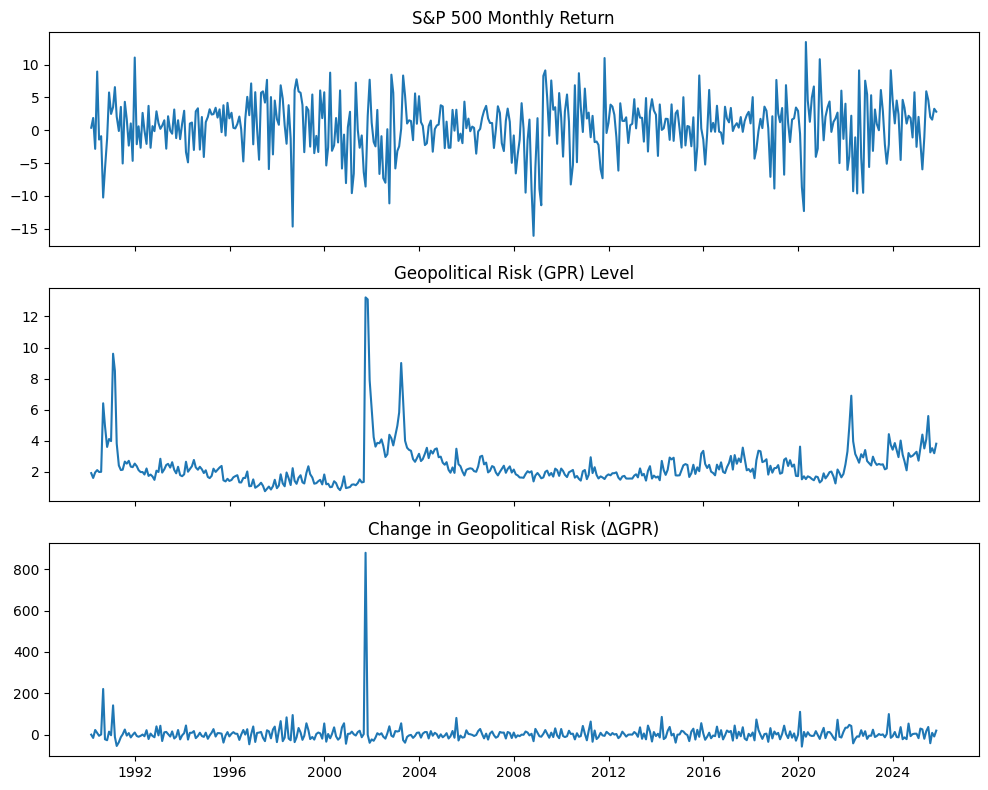

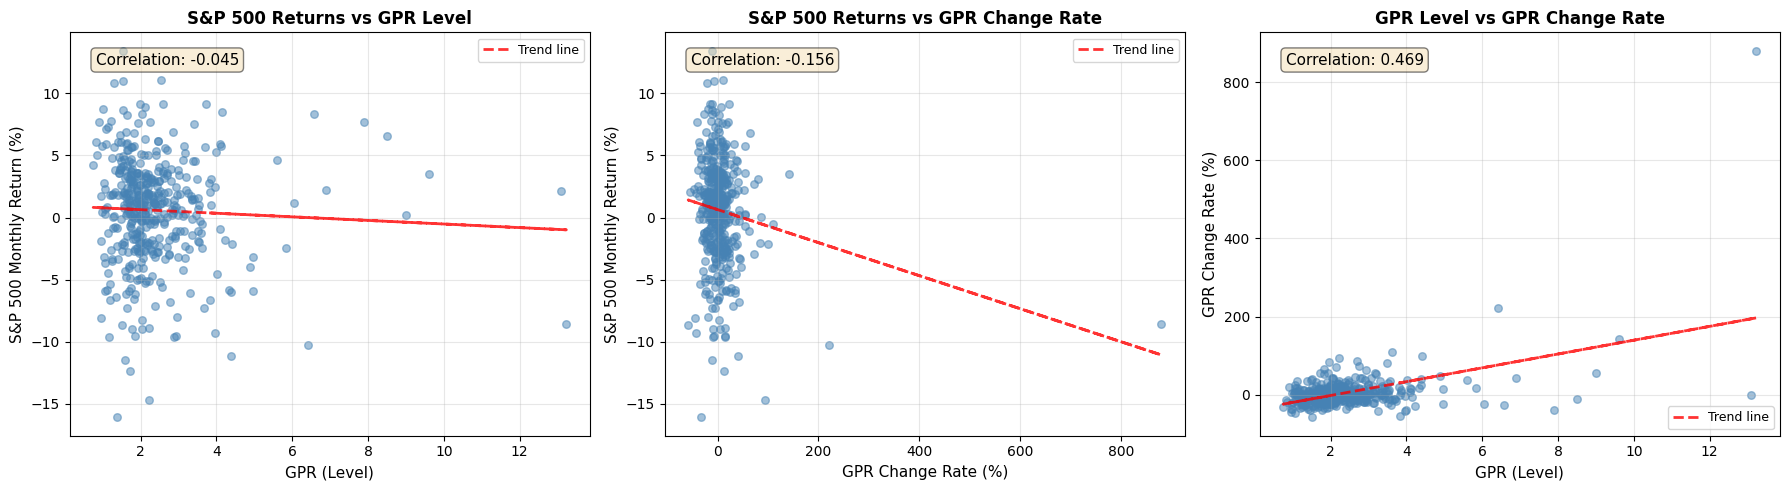

Correlation matrix (returns vs GPR variables):
           sp500_ret       gpr   gpr_chg
sp500_ret   1.000000 -0.044973 -0.155866
gpr        -0.044973  1.000000  0.469416
gpr_chg    -0.155866  0.469416  1.000000

=== Model 1: sp500_ret ~ GPR (level) ===
                            OLS Regression Results                            
Dep. Variable:              sp500_ret   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9660
Date:                Fri, 12 Dec 2025   Prob (F-statistic):              0.326
Time:                        13:35:00   Log-Likelihood:                -1229.6
No. Observations:                 429   AIC:                             2463.
Df Residuals:                     427   BIC:                             2471.
Df Model:                           1                                         
Covariance Type:                  HA

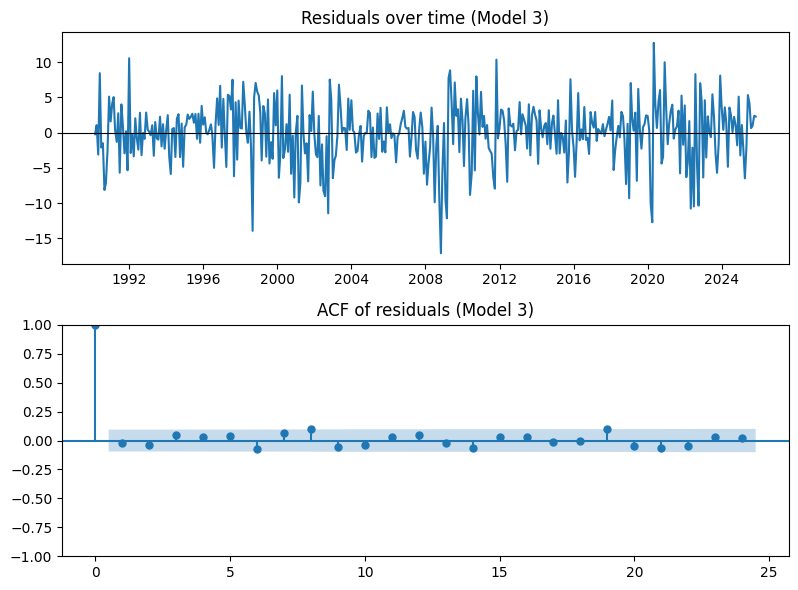

In [48]:
import statsmodels.api as sm
df = merged_monthly_df_clean_with_changes.copy()


# Rename columns to simpler names (adjust if your exact names differ)
df = df.rename(columns={
    "SP500 CHANGE RATE": "sp500_ret",
    "GPRC_USA": "gpr",
    "GPRC CHANGE RATE": "gpr_chg"
})

# Keep only the columns we need and drop missing values
data = df[["sp500_ret", "gpr", "gpr_chg"]].dropna()

# ===== 1. Quick exploratory plots (Time Series) =====
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(data.index, data["sp500_ret"])
axes[0].set_title("S&P 500 Monthly Return")

axes[1].plot(data.index, data["gpr"])
axes[1].set_title("Geopolitical Risk (GPR) Level")

axes[2].plot(data.index, data["gpr_chg"])
axes[2].set_title("Change in Geopolitical Risk (ΔGPR)")

plt.tight_layout()
plt.show()

# ===== 1.5. Scatter Plots: S&P 500 Returns vs GPR Variables =====
# Visualize relationships before computing correlations

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. sp500_ret vs gpr (level)
ax = axes[0]
x1 = data["gpr"]
y1 = data["sp500_ret"]
ax.scatter(x1, y1, alpha=0.5, s=30, color='steelblue')
corr1 = x1.corr(y1)
ax.text(0.05, 0.95, f'Correlation: {corr1:.3f}', 
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
z1 = np.polyfit(x1, y1, 1)
p1 = np.poly1d(z1)
ax.plot(x1, p1(x1), "r--", alpha=0.8, linewidth=2, label='Trend line')
ax.set_xlabel('GPR (Level)', fontsize=11)
ax.set_ylabel('S&P 500 Monthly Return (%)', fontsize=11)
ax.set_title('S&P 500 Returns vs GPR Level', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

# 2. sp500_ret vs gpr_chg (change rate)
ax = axes[1]
x2 = data["gpr_chg"]
y2 = data["sp500_ret"]
ax.scatter(x2, y2, alpha=0.5, s=30, color='steelblue')
corr2 = x2.corr(y2)
ax.text(0.05, 0.95, f'Correlation: {corr2:.3f}', 
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
z2 = np.polyfit(x2, y2, 1)
p2 = np.poly1d(z2)
ax.plot(x2, p2(x2), "r--", alpha=0.8, linewidth=2, label='Trend line')
ax.set_xlabel('GPR Change Rate (%)', fontsize=11)
ax.set_ylabel('S&P 500 Monthly Return (%)', fontsize=11)
ax.set_title('S&P 500 Returns vs GPR Change Rate', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

# 3. gpr vs gpr_chg
ax = axes[2]
x3 = data["gpr"]
y3 = data["gpr_chg"]
ax.scatter(x3, y3, alpha=0.5, s=30, color='steelblue')
corr3 = x3.corr(y3)
ax.text(0.05, 0.95, f'Correlation: {corr3:.3f}', 
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
z3 = np.polyfit(x3, y3, 1)
p3 = np.poly1d(z3)
ax.plot(x3, p3(x3), "r--", alpha=0.8, linewidth=2, label='Trend line')
ax.set_xlabel('GPR (Level)', fontsize=11)
ax.set_ylabel('GPR Change Rate (%)', fontsize=11)
ax.set_title('GPR Level vs GPR Change Rate', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ===== 2. Simple correlations =====
print("Correlation matrix (returns vs GPR variables):")
print(data[["sp500_ret", "gpr", "gpr_chg"]].corr())

# ===== 3. OLS regressions with HAC (Newey–West) standard errors =====
# We use 12 lags since this is monthly data (1 year)

y = data["sp500_ret"]

# --- Model 1: Return ~ GPR level ---
X1 = sm.add_constant(data["gpr"])
model1 = sm.OLS(y, X1).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
print("\n=== Model 1: sp500_ret ~ GPR (level) ===")
print(model1.summary())

# --- Model 2: Return ~ GPR change ---
X2 = sm.add_constant(data["gpr_chg"])
model2 = sm.OLS(y, X2).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
print("\n=== Model 2: sp500_ret ~ ΔGPR ===")
print(model2.summary())

# --- Model 3: Return ~ GPR level + GPR change ---
X3 = sm.add_constant(data[["gpr", "gpr_chg"]])
model3 = sm.OLS(y, X3).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
print("\n=== Model 3: sp500_ret ~ GPR + ΔGPR ===")
print(model3.summary())

# ===== 4. Optional: residual diagnostics for the preferred model =====
resid = model3.resid

fig, axes = plt.subplots(2, 1, figsize=(8, 6))
axes[0].plot(resid)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title("Residuals over time (Model 3)")

sm.graphics.tsa.plot_acf(resid, lags=24, ax=axes[1])
axes[1].set_title("ACF of residuals (Model 3)")

plt.tight_layout()
plt.show()

In [49]:
import pandas as pd
#Compute a lead–lag Spearman correlation analysis to identify whether macro/geopolitical variables lead (predict) S&P 500 monthly returns at lags 0–6.
merged_df = merged_monthly_df_clean_with_changes.copy()

# Target: month-to-month change in S&P 500
sp = merged_df['SP500 CHANGE RATE']

# Predictors: month-to-month changes in the other indicators
predictors = [
    'GPRC CHANGE RATE',
    'FEDFUNDS CHANGE RATE',
    'CPI CHANGE RATE',
    'UNEMPLOYMENT RATE CHANGE RATE',
    'VIX CHANGE RATE'
]

lag_results = []

for var in predictors:
    for lag in range(0, 7):  # 0 = same month, 1–6 months lag
        shifted = merged_df[var].shift(lag)
        corr = sp.corr(shifted, method='spearman')  
        lag_results.append([var, lag, corr])

lag_df = pd.DataFrame(
    lag_results,
    columns=['Variable', 'Lag_months', 'Spearman_Correlation']
).sort_values(by='Spearman_Correlation', ascending=False)

#return variables with Spearman correlation above a threshold of 0.20
lag_df[lag_df['Spearman_Correlation'].abs() > 0.20]


,Variable,Lag_months,Spearman_Correlation
28,VIX CHANGE RATE,0,-0.514892


In [50]:
import pandas as pd
import matplotlib.pyplot as plt
# Compute rolling 6-month cumulative geopolitical pressure and rolling 6-month S&P volatility
# to test whether prolonged geopolitical tension corresponds to prolonged market instability.

window = 6  # 6 months

# 6-month cumulative geopolitical pressure
merged_df['GPR_pressure_6m'] = merged_df['GPRC CHANGE RATE'].rolling(window).sum()

# 6-month rolling volatility of S&P 500 returns
merged_df['SP500_vol_6m'] = merged_df['SP500 CHANGE RATE'].rolling(window).std()

merged_df[['GPR_pressure_6m', 'SP500_vol_6m']].tail(10)

,GPR_pressure_6m,SP500_vol_6m
Date,,
2025-01-31,38.819528,2.906388
2025-02-28,14.835055,3.138771
2025-03-31,47.553665,4.052290
2025-04-30,25.154087,4.051507
2025-05-30,37.668524,4.097035
2025-06-30,70.201362,4.437550
2025-07-31,45.736127,4.436206
2025-08-29,24.801398,4.273296
2025-09-30,-9.622455,2.459826


In [51]:
merged_df[['GPR_pressure_6m', 'SP500_vol_6m']].corr(method='spearman')

,GPR_pressure_6m,SP500_vol_6m
GPR_pressure_6m,1.000000,0.104934
SP500_vol_6m,0.104934,1.000000


In [52]:
from scipy.stats import f_oneway
#Perform anova tests with SP500 monthly returns as the dependent variable, across low, medium, and high regimes
# for each economic/geopolitical indicator(based on quantile bins). 
def anova_test(df, group_col, ret_col="SP500 CHANGE RATE"):
    df = df.copy()
    #Test based on a quantile cut
    df["group"] = pd.qcut(df[group_col], 3, labels=["Low", "Med", "High"])
    g1 = df[df["group"]=="Low"][ret_col]
    g2 = df[df["group"]=="Med"][ret_col]
    g3 = df[df["group"]=="High"][ret_col]
    F, p = f_oneway(g1, g2, g3)
    return {"Variable": group_col, "F": F, "p": p}

variables = [
    "GPRC CHANGE RATE", "VIX CHANGE RATE", "CPI CHANGE RATE",
    "FEDFUNDS CHANGE RATE", "UNEMPLOYMENT RATE CHANGE RATE"
]

anova_results = [anova_test(merged_df, var) for var in variables]
pd.DataFrame(anova_results).sort_values("p")


,Variable,F,p
1,VIX CHANGE RATE,52.897957,3.023851e-21
0,GPRC CHANGE RATE,2.626744,7.348459e-02
3,FEDFUNDS CHANGE RATE,2.290286,1.024828e-01
2,CPI CHANGE RATE,1.369829,2.552703e-01
4,UNEMPLOYMENT RATE CHANGE RATE,1.107678,3.312789e-01


## 📌 Summary of Analysis

Our analysis examined whether geopolitical risk and major macroeconomic indicators (GPR, Federal Funds Rate, CPI, Unemployment, VIX) meaningfully influence monthly S&P 500 returns. We applied multiple statistical approaches to evaluate both predictive power and regime effects.

---

### 🔷 **1. Lead–Lag Correlation (0–6 Months)**

We tested whether monthly macro and geopolitical indicators *lead* S&P 500 returns by 0–6 months using Spearman correlation.

> **Result:** Correlations were consistently very small (**|ρ| < 0.10** across all variables and lags)

📌 **Interpretation:** These variables do **not** meaningfully predict S&P 500 returns over the following months.  
Markets appear to price in macro/geopolitical information quickly.

---

### 🔷 **2. Rolling 6-Month Window Analysis**

We constructed:
- **6-month cumulative geopolitical pressure**, and
- **6-month rolling volatility of S&P 500 returns**

> **Result:** Spearman correlation ≈ **0.106** between rolling GPR pressure and S&P 500 volatility

📌 **Interpretation:** Sustained geopolitical tension is associated with **higher market volatility**,  
but **does not reliably predict whether returns will be positive or negative**.

---

### 🔷 **3. ANOVA Regime Testing**

Each indicator was split into **Low / Medium / High** regimes (via quantile bins), and we tested whether mean S&P 500 returns differed across the regimes.

| Indicator | Statistically Significant? |
|----------|-----------------------------|
| **VIX Change Rate** | ✔ **Yes (p ≪ 0.001)** |
| GPR Change Rate | ❌ No |
| Federal Funds Change Rate | ❌ No |
| CPI Change Rate | ❌ No |
| Unemployment Rate Change Rate | ❌ No |

📌 **Interpretation:** Only **rapid fluctuations in volatility (VIX)** correspond to meaningful differences in market return environments. Other indicators do not shift average return outcomes.

---

### 🔷 **4. Inference: Geopolitical Risk → S&P 500 Returns**

We regress monthly S&P 500 returns on:

- **GPR level** (GPR)  
- **Change in GPR** (ΔGPR)  

### **Key Findings**

#### **Model 1 — Return ~ GPR Level**
- Coefficient not significant  
- No explanatory power  
➡️ **Background geopolitical tension does not affect returns**

#### **Model 2 — Return ~ ΔGPR**
- Coefficient **negative and highly significant**  
- Returns fall when geopolitical risk increases  
➡️ **Markets respond to geopolitical shocks, not levels**

#### **Model 3 — Return ~ GPR + ΔGPR**
- GPR level remains insignificant  
- ΔGPR remains significantly negative  
➡️ **Effect of geopolitical shocks is robust**

**In short:**  
> The S&P 500 reacts to **changes** in geopolitical risk, not to the steady level of geopolitical tension.


## Research Question 2
## Is GPR Collinear With Other Financial Features

In [53]:
df.columns

Index(['SP500 Index Value ($)', 'sp500_ret', 'date_month', 'gpr', 'gpr_chg',
       'FEDFUNDS', 'FEDFUNDS CHANGE RATE', 'CPI', 'CPI CHANGE RATE',
       'UNEMPLOYMENT RATE', 'UNEMPLOYMENT RATE CHANGE RATE', 'VIX',
       'VIX CHANGE RATE'],
      dtype='object')

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. Select the correct merged dataframe
# ============================================================

if 'merged_monthly_df_clean_with_changes' in globals():
    df = merged_monthly_df_clean_with_changes.copy()
elif 'merged_monthly_df_with_changes' in globals():
    df = merged_monthly_df_with_changes.copy()
else:
    df = merged_monthly_df.copy()

# ============================================================
# 2. Choose correct column names for collinearity analysis
# ============================================================

cols = [
    "GPRC_USA",
    "FEDFUNDS",
    "CPI",
    "UNEMPLOYMENT RATE",
    "VIX"
]

# Drop missing rows to compute correlations cleanly
df_corr = df[cols].dropna()

# ============================================================
# 3. Compute Pearson correlation matrix
# ============================================================

corr_matrix = df_corr.corr(method="pearson")
corr_matrix


,GPRC_USA,FEDFUNDS,CPI,UNEMPLOYMENT RATE,VIX
GPRC_USA,1.000000,-0.026196,0.089820,-0.115472,0.096494
FEDFUNDS,-0.026196,1.000000,-0.439324,-0.444024,-0.091504
CPI,0.089820,-0.439324,1.000000,-0.202218,-0.011468
UNEMPLOYMENT RATE,-0.115472,-0.444024,-0.202218,1.000000,0.192540
VIX,0.096494,-0.091504,-0.011468,0.192540,1.000000


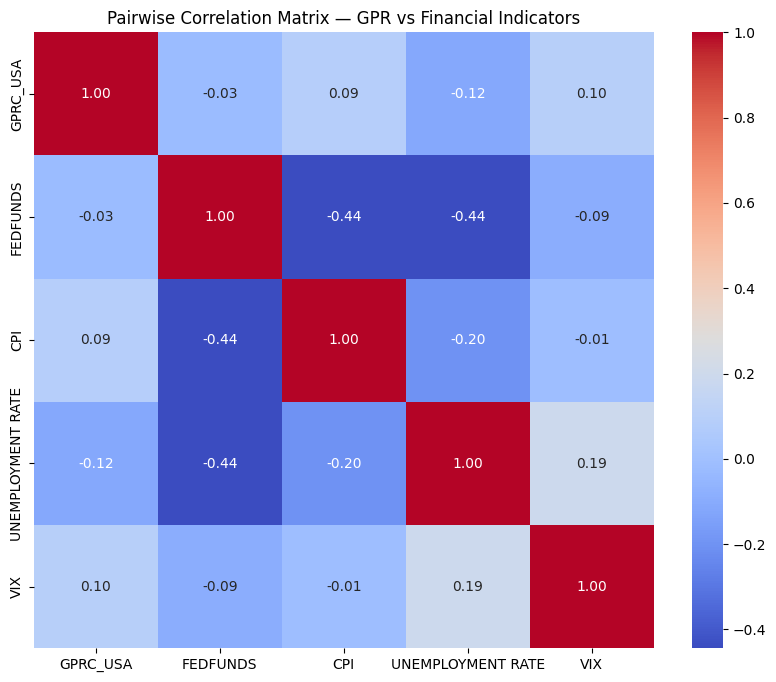

In [55]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Pairwise Correlation Matrix — GPR vs Financial Indicators")
plt.show()

## Permutation-Based Correlation Testing (with Multiple-Testing Correction)

### Goal
To test whether **GPR (geopolitical risk)** or **GPR Change Rate** is statistically correlated with major financial indicators.  
Because we perform 16 simultaneous tests, we use **permutation tests** for robust p-values and apply **FDR correction** to control the false discovery rate.

### Method
For each pair (GPR variable, financial variable):

1. Compute the observed Pearson correlation.
2. Permute the financial variable 5,000 times.
3. Build a null distribution of correlations.
4. Compute a two-sided permutation p-value.
5. Apply **Benjamini–Hochberg FDR correction** across all tests.
6. Plot the permutation null distribution as a boxplot and mark the observed correlation.

### Interpretation
- If the observed value lies far outside the boxplot, the correlation is unlikely under the null model.
- FDR-corrected p-values identify which correlations remain significant after adjusting for multiple testing.
- In practice, most correlations involving GPR or GPR Change Rate are **not significant**, confirming that geopolitical risk is **not collinear** with standard financial indicators.

The resulting boxplots visualize both the null distributions and the observed correlations with corrected significance annotations.


,GPR variable,Financial variable,Observed correlation,Permutation p-value,FDR p-value,Significant (FDR<0.05)
0,GPRC_USA,FEDFUNDS,-0.023986,0.6264,0.784457,False
1,GPRC_USA,FEDFUNDS CHANGE RATE,0.067881,0.1418,0.324114,False
2,GPRC_USA,CPI,0.092525,0.0544,0.174080,False
3,GPRC_USA,CPI CHANGE RATE,0.045108,0.3416,0.607289,False
4,GPRC_USA,UNEMPLOYMENT RATE,-0.115472,0.0192,0.123733,False
5,GPRC_USA,UNEMPLOYMENT RATE CHANGE RATE,0.009741,0.7674,0.818560,False
6,GPRC_USA,VIX,0.095096,0.0438,0.174080,False
7,GPRC_USA,VIX CHANGE RATE,0.024786,0.5836,0.784457,False
8,GPRC CHANGE RATE,FEDFUNDS,0.024123,0.6864,0.784457,False
9,GPRC CHANGE RATE,FEDFUNDS CHANGE RATE,-0.045303,0.1830,0.366000,False


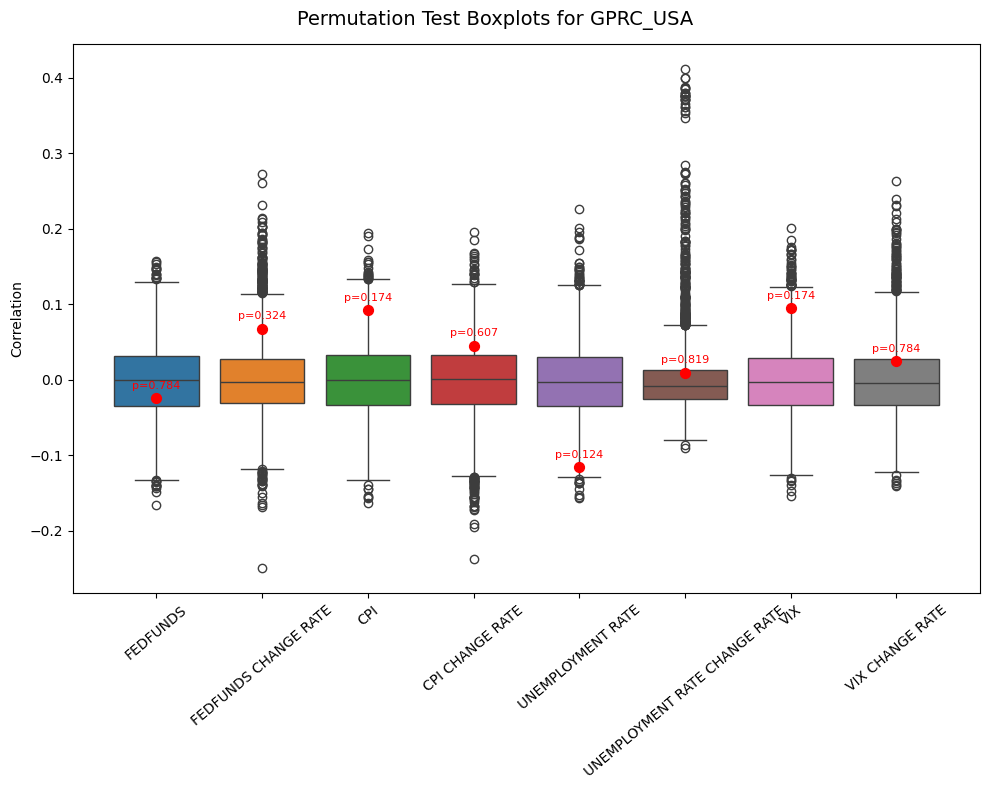

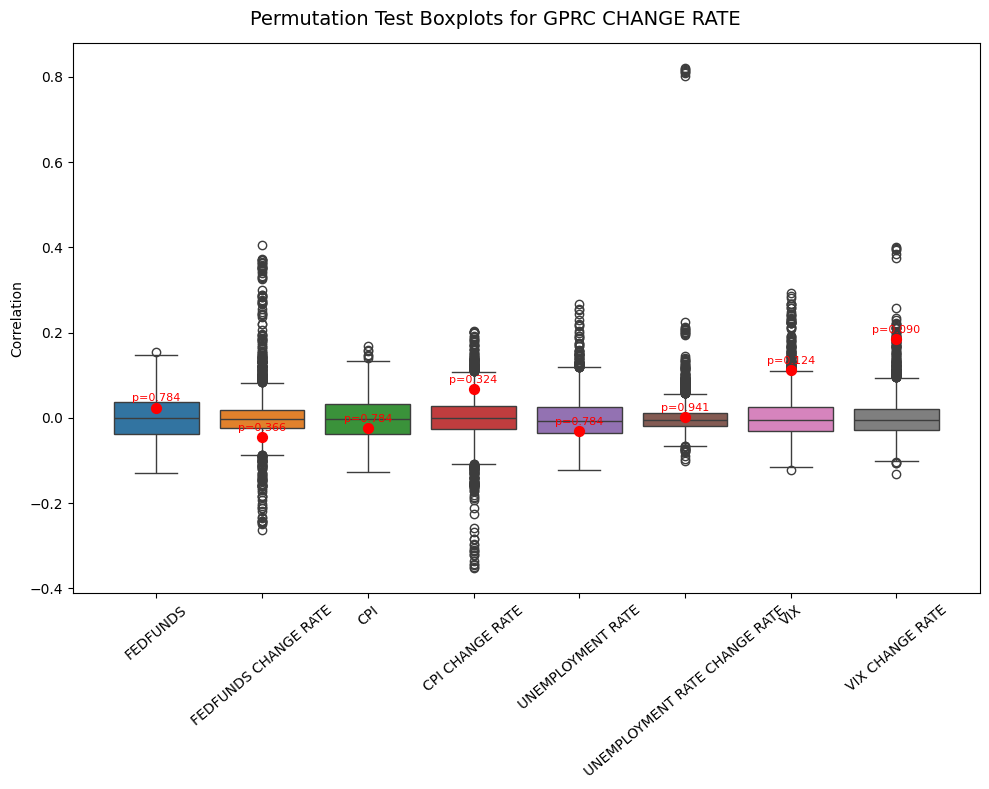

In [56]:
import seaborn as sns
from statsmodels.stats.multitest import multipletests

df = merged_monthly_df_clean_with_changes.copy()

gpr_vars = ["GPRC_USA", "GPRC CHANGE RATE"]

financial_vars = [
    "FEDFUNDS",
    "FEDFUNDS CHANGE RATE",
    "CPI",
    "CPI CHANGE RATE",
    "UNEMPLOYMENT RATE",
    "UNEMPLOYMENT RATE CHANGE RATE",
    "VIX",
    "VIX CHANGE RATE"
]

N_PERM = 5000
rng = np.random.default_rng(123)

results = []
all_nulls = {}

def perm_test_corr(x, y, n_perm=5000):
    x, y = np.array(x), np.array(y)
    mask = ~np.isnan(x) & ~np.isnan(y)
    x, y = x[mask], y[mask]
    
    obs = np.corrcoef(x, y)[0, 1]
    
    perms = np.zeros(n_perm)
    for i in range(n_perm):
        perms[i] = np.corrcoef(x, rng.permutation(y))[0, 1]
        
    p_val = np.mean(np.abs(perms) >= np.abs(obs))
    return obs, p_val, perms

# Run permutation tests
for gpr in gpr_vars:
    for var in financial_vars:
        obs, p, null = perm_test_corr(df[gpr], df[var], N_PERM)

        results.append({
            "GPR variable": gpr,
            "Financial variable": var,
            "Observed correlation": obs,
            "Permutation p-value": p
        })

        all_nulls[(gpr, var)] = (obs, null)

results_df = pd.DataFrame(results)

# FDR Correction
raw_p = results_df["Permutation p-value"].values
rej, p_corr, _, _ = multipletests(raw_p, alpha=0.05, method="fdr_bh")

results_df["FDR p-value"] = p_corr
results_df["Significant (FDR<0.05)"] = rej

display(results_df)

# Boxplots (with corrected p-values)
for gpr in gpr_vars:
    plt.figure(figsize=(10, 8))
    plt.suptitle(f"Permutation Test Boxplots for {gpr}", fontsize=14)

    data_to_plot = []
    labels = []
    obs_points = []
    pvals = []

    for var in financial_vars:
        obs, null = all_nulls[(gpr, var)]
        data_to_plot.append(null)
        labels.append(var)
        obs_points.append(obs)

        # corrected p-value
        p_corr = results_df[
            (results_df["GPR variable"] == gpr) &
            (results_df["Financial variable"] == var)
        ]["FDR p-value"].values[0]
        
        pvals.append(p_corr)

    sns.boxplot(data=data_to_plot)
    plt.xticks(ticks=np.arange(len(labels)), labels=labels, rotation=40)

    # Plot observed correlation as red dots
    for i, obs in enumerate(obs_points):
        plt.scatter(i, obs, color="red", s=50, zorder=5)
        plt.text(i, obs + 0.01, f"p={pvals[i]:.3f}",
                 ha="center", va="bottom", color="red", fontsize=8)

    plt.ylabel("Correlation")
    plt.tight_layout()
    plt.show()


## PCA Analysis: Collinearity Between GPR and Financial Indicators

### Goal
To test whether **Geopolitical Risk (GPR)** or **GPR Change Rate** is collinear with other financial variables (Fed Funds, CPI, Unemployment, VIX, etc.). PCA is used because it detects shared variance across *all* variables, not just pairwise correlations.

### Method
We perform PCA on all macro-financial features plus GPR variables.  
Interpretation rule:
- Variables loading strongly on the **same principal component (PC)** → share variance → potential collinearity.
- Variables loading on **distinct PCs** → independent patterns → no collinearity.

### Results
- **GPR** and **GPR Change Rate** load heavily on **PC2 and PC9**.
- Financial indicators (CPI, unemployment, VIX, Fed Funds) load on **different PCs** such as PC1, PC3, PC5, PC6, PC7, and PC10.
- **No major financial variable loads strongly on PC2 or PC9**, meaning they do not share variance with GPR.

### Conclusion
PCA shows **no evidence of multicollinearity** between GPR/GPR Change and the standard financial indicators.  
Geopolitical risk forms its **own independent statistical dimension**, consistent with regression results showing that GPR has limited direct impact on S&P 500 returns.

Heatmaps and biplots included in the notebook visualize this separation clearly.



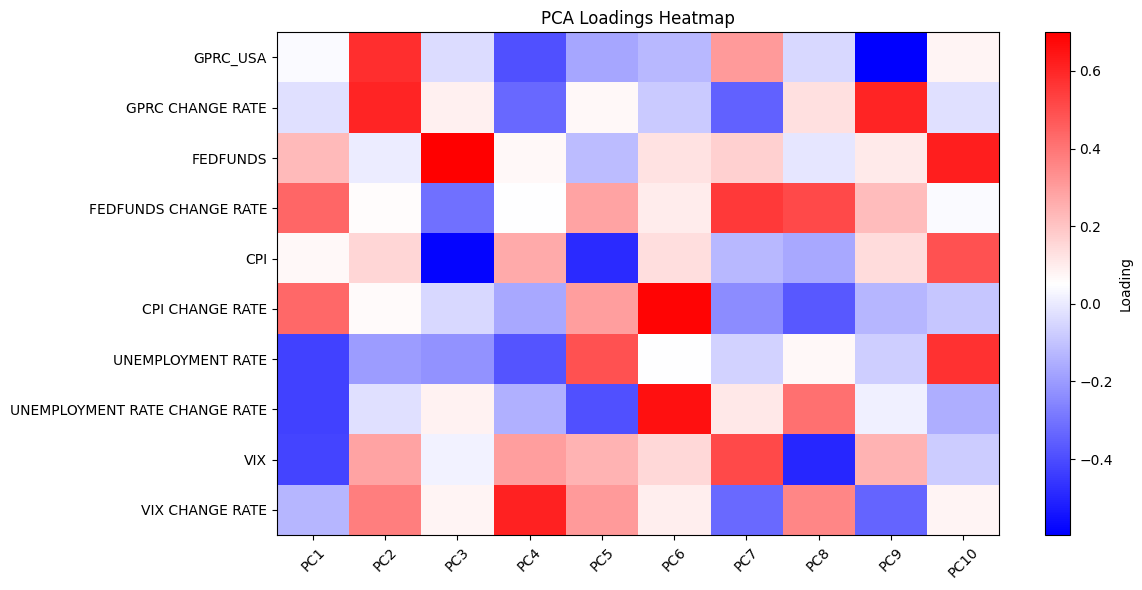

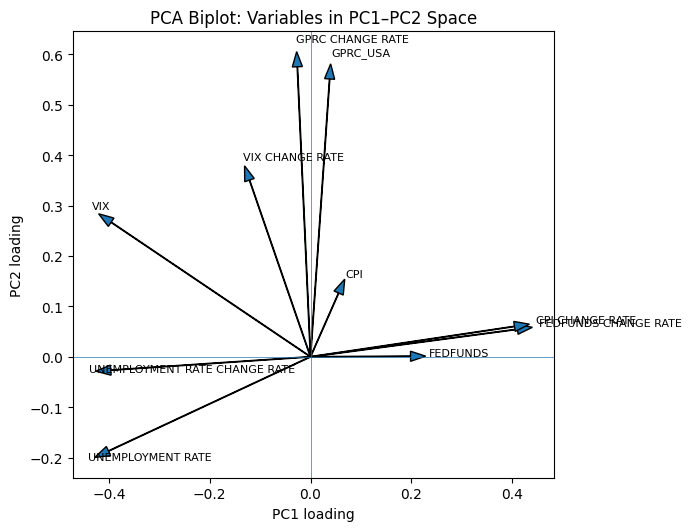

In [57]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Conduct PCA
index = index = [
    "GPRC_USA",
    "GPRC CHANGE RATE",
    "FEDFUNDS",
    "FEDFUNDS CHANGE RATE",
    "CPI",
    "CPI CHANGE RATE",
    "UNEMPLOYMENT RATE",
    "UNEMPLOYMENT RATE CHANGE RATE",
    "VIX",
    "VIX CHANGE RATE",
]
X = df[index].dropna()

X_scaled = StandardScaler().fit_transform(X)
pca = PCA().fit(X_scaled)

loadings_df = pd.DataFrame(pca.components_.T,
                        columns=[f"PC{i+1}" for i in range(X.shape[1])],
                        index=X.columns)

# 2. Heatmap of PCA loadings
plt.figure(figsize=(12, 6))
plt.imshow(loadings_df.values, aspect="auto", cmap="bwr")
plt.colorbar(label="Loading")
plt.xticks(np.arange(len(loadings_df.columns)), loadings_df.columns, rotation=45)
plt.yticks(np.arange(len(loadings_df.index)), loadings_df.index)
plt.title("PCA Loadings Heatmap")
plt.tight_layout()
plt.show()

# 3. PC1 vs PC2 biplot
plt.figure(figsize=(7, 7))
x = loadings_df["PC1"]
y = loadings_df["PC2"]

plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)

for var, xi, yi in zip(loadings_df.index, x, y):
    plt.arrow(0, 0, xi, yi, head_width=0.02, length_includes_head=True)
    plt.text(xi * 1.03, yi * 1.03, var, fontsize=8)

plt.xlabel("PC1 loading")
plt.ylabel("PC2 loading")
plt.title("PCA Biplot: Variables in PC1–PC2 Space")
plt.gca().set_aspect("equal", "box")
plt.tight_layout()
plt.show()

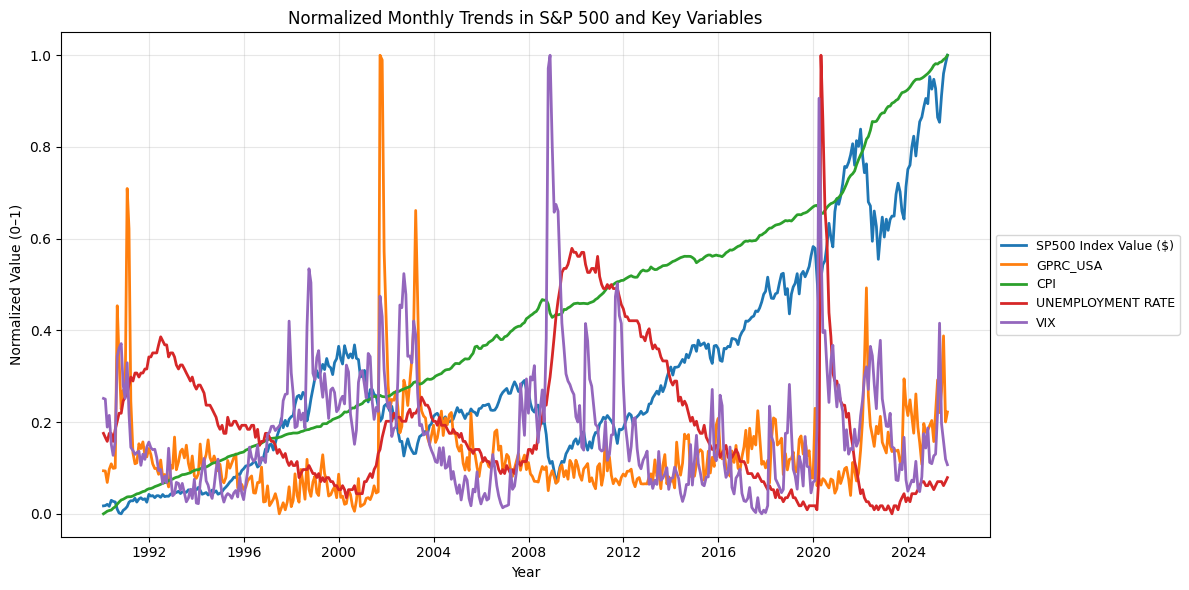

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Pick dataframe
if 'merged_monthly_df_with_changes' in globals():
    df = merged_monthly_df_with_changes.copy()
elif 'merged_monthly_df' in globals():
    df = merged_monthly_df.copy()
else:
    raise ValueError("Run the earlier cells that create the monthly merged dataframe first.")

# 2. Ensure datetime index
if not isinstance(df.index, pd.DatetimeIndex):
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.set_index('Date')
    elif 'date_month' in df.columns:
        df['date_month'] = pd.to_datetime(df['date_month'].astype(str).str.replace('.', '-') + '-01', errors='coerce')
        df = df.set_index('date_month')
    else:
        raise ValueError("No 'Date' or 'date_month' column available.")

df = df.sort_index()

# 3. Auto-detect columns
def find_col(keyword):
    keyword = keyword.upper()
    candidates = [c for c in df.columns if keyword in c.upper()]
    return candidates[0] if candidates else None

sp_col = find_col('SP500')
gpr_col = find_col('GPR')
cpi_col = find_col('CPI')
unemp_col = find_col('UNEMPLOYMENT')
vix_col = find_col('VIX')

cols_to_plot = [c for c in [sp_col, gpr_col, cpi_col, unemp_col, vix_col] if c is not None]

if len(cols_to_plot) < 2:
    raise ValueError("Not enough expected columns found (SP500, GPR, CPI, UNEMPLOYMENT, VIX).")

plot_df = df[cols_to_plot].dropna()

# 4. Normalize each series
norm_df = plot_df.copy()
for col in norm_df.columns:
    col_min = norm_df[col].min()
    col_max = norm_df[col].max()
    if col_max > col_min:
        norm_df[col] = (norm_df[col] - col_min) / (col_max - col_min)

# 5. Plot
plt.figure(figsize=(12, 6))
for col in norm_df.columns:
    plt.plot(norm_df.index, norm_df[col], label=col, linewidth=2)

plt.title("Normalized Monthly Trends in S&P 500 and Key Variables")
plt.xlabel("Year")
plt.ylabel("Normalized Value (0–1)")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()